# Setting

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

llm4o = ChatOpenAI(
    openai_api_key = os.getenv('OPENAI_API_KEY'),
    model='gpt-4o',
    temperature=1,
)

llm = ChatOpenAI(
    openai_api_key = os.getenv('OPENAI_API_KEY'),
    model='gpt-4o-mini',
    temperature=1,
)

# 買進賣出需要的手續費
fee = {
    'tax_stock' : 0.003,          # 買進與賣出各0.003
    'tax_future' : 0.00002 * 2,   # 買進與賣出各0.00002
    'fee_stock' : 0.001425 * 2,   # 券商手續費公道價，買進與賣出各0.001425
    'fee_future' : 0.00002 * 2,   # 個家不大相同，以交易稅計算
    'sliding_price' : 0.00001,    # 滑價
}

data = [
    ["2330", "台積電", "tw"],
    ["2317", "鴻海", "tw"],
    ["2454", "聯發科", "tw"],
    ["2382", "廣達", "tw"],
    ["3231", "緯創", "tw"],
    # ["2324","仁寶", "tw"],
    # ["4938", "和碩", "tw"],
    # ["2356","英業達", "tw"],
    # ["2881", "富邦金", "tw"],
    # ["2882", "國泰金", "tw"],
    # ["2412", "中華電", "tw"],
    # ["3045", "台灣大", "tw"],
    # ["6505", "台塑化", "tw"],
    # ["2603", "長榮", "tw"],
    
    ["AAPL", "Apple Inc.", "us"],
    ["GOOGL", "Google", "us"],
    ["MSFT", "Microsoft", "us"],
    ["AMZN", "Amazon inc.", "us"],
    ["TSLA", "Tesla", "us"],
    ["NVDA", "Nvidia", "us"],
    # ["META", "Meta Platforms", "us"],
    # ["BRK", "Berkshire Hathaway", "us"],
]

date_ranges = [
    ["20230401", "20240331", "2024Q1"],
    ["20230701", "20240630", "2024Q2"],
    ["20231001", "20240930", "2024Q3"],
    # ["20240101", "20241231", "2024Q4"],
]

def get_balance_list(list_rtn, start_price):
    balance = start_price
    list_balance = []
    for rtn in list_rtn:
        balance = balance * (1 + float(rtn))
        list_balance.append(balance)
    return list_balance

# env = {
#     "stock_id" : "NVDA",
#     "stock_name" : "Nvidia",
#     "country" : "us",
#     "start_date" : "20230401",
#     "end_date" : "20240331",
# }

# On(Over Night)另一種評分作法，正面就持續持有，負面就賣出
# 只跑有用的factor

In [2]:
from factor import Factor
for stock in data:
    env = {
        "stock_id" : stock[0],
        "stock_name" : stock[1],
        "country" : stock[2],
        "start_date" : "20230401",
        "end_date" : "20240331",
    }
    print(env['stock_id'], env['stock_name'], env['country'])

    eval_module = Factor(env)
    a = eval_module.get_expand(show_sig=True)
    
    print(eval_module.get_individual(mode=1))
    

2330 台積電 tw
  20230406 =>   1   1   1   1   1   1   1   1   1   1  -1  -1   1   0   1  -1  -1  -1  -1  -1 
  20230407 =>   1   1  -1   1   1   0   1  -1  -1   1  -1  -1  -1  -1   1   1  -1  -1  -1  -1 
  20230410 =>   1   1   1   1   1   1   1   1   1   1  -1  -1   1   0   1   0   1  -1   1  -1 
  20230411 =>   1   1   1   1   1   0   1   1   1   1  -1   1   1  -1   1  -1  -1  -1   1  -1 
  20230412 =>  -1   1  -1   1   1   0  -1  -1  -1   0  -1  -1   1  -1   1  -1  -1  -1  -1  -1 
  20230413 =>  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1  -1   1  -1   1  -1  -1  -1  -1  -1 
  20230414 =>   1   1   1   1   1   1   1   1   1   1  -1  -1   1   0  -1  -1  -1  -1  -1  -1 
  20230417 =>   1   0   0   1   1   0   0   0   1   1  -1   1   1  -1  -1  -1  -1  -1  -1  -1 
  20230418 =>   1   1   1   1   1   1   1  -1   1   1   0  -1   1   0  -1   0  -1  -1  -1  -1 
  20230419 =>   1   1   1   1   1   1   1   1   1   1  -1   1   1  -1   1   0  -1  -1  -1  -1 
  20230420 =>   1   1   0   1   1   1 

In [3]:
# for stock in data:
#     env = {
#         "stock_id" : stock[0],
#         "stock_name" : stock[1],
#         "country" : stock[2],
#         "start_date" : "20230401",
#         "end_date" : "20240331",
#     }
#     print(env['stock_id'], env['stock_name'], env['country'])
#     path_folder = "out_stock/GA_factor_" 
#     path_out = path_folder + env['start_date'] + "_" + env['end_date'] + "/" + env['stock_id'] + "/"
#     path_factors = f"{path_out}/factors.json"
#     path_result = f"{path_out}/ev/result.json"

#     with open(path_result, 'r') as f:
#         result = json.load(f)
#         individuals = result['individual']
    
#     with open(path_factors , 'r') as f:
#         factors = json.load(f)
#     i = 0
#     for key, value in factors.items():
#         if individuals[i] == 1:
#             print(key, value)
#         i += 1
#     print("")

# Method 1

1
2330 台積電 tw 2024Q1


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.535135,0.500000,0.001616,0.000949,185,61,61,38,25
test,0.517857,0.458333,0.001986,0.000941,56,22,26,7,1


2330 台積電 tw 2024Q2


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.516484,0.493151,0.001138,0.000681,182,72,74,22,14
test,0.622951,0.574468,0.004595,0.003718,61,27,20,11,3


2330 台積電 tw 2024Q3


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.555556,0.536424,0.002333,0.001783,180,81,70,19,10
test,0.571429,0.541667,0.004054,0.003256,63,26,22,10,5


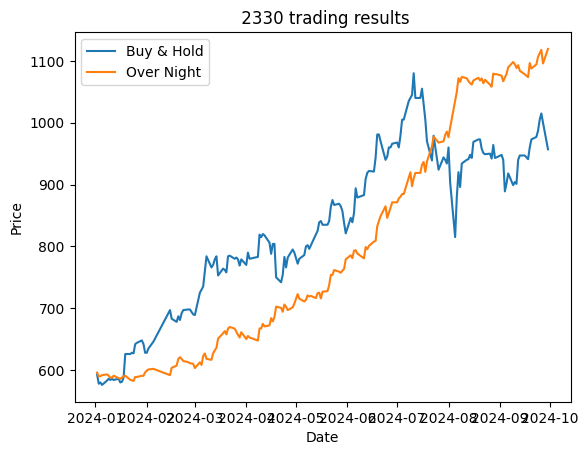

2317 鴻海 tw 2024Q1


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.427027,0.378049,0.001434,0.000458,185,31,51,48,55
test,0.446429,0.481481,0.004427,0.008026,56,13,14,12,17


2317 鴻海 tw 2024Q2


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.453039,0.416667,0.002029,0.001688,181,45,63,37,36
test,0.459016,0.441860,0.003714,0.004955,61,19,24,9,9


2317 鴻海 tw 2024Q3


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.477778,0.512500,0.004130,0.006891,180,41,39,45,55
test,0.619048,0.571429,0.005945,0.004825,63,16,12,23,12


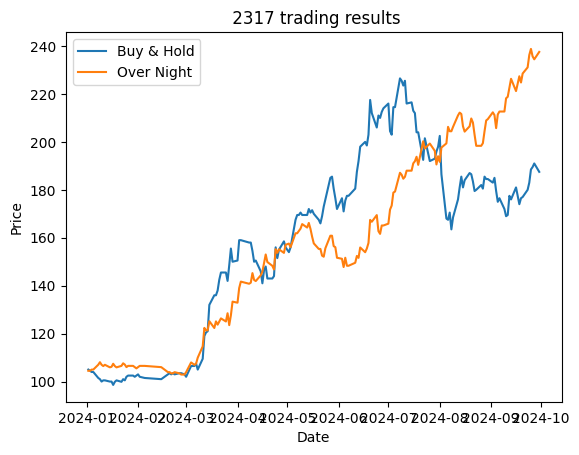

2454 聯發科 tw 2024Q1


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.491892,0.444444,0.001489,0.001097,185,48,60,43,34
test,0.517857,0.447368,0.004634,0.002934,56,17,21,12,6


2454 聯發科 tw 2024Q2


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.532967,0.472973,0.003059,0.001841,182,70,78,27,7
test,0.508197,0.479167,0.003015,0.001430,61,23,25,8,5


2454 聯發科 tw 2024Q3


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.522222,0.486486,0.003672,0.002160,180,72,76,22,10
test,0.507937,0.432432,0.003284,0.003697,63,16,21,16,10


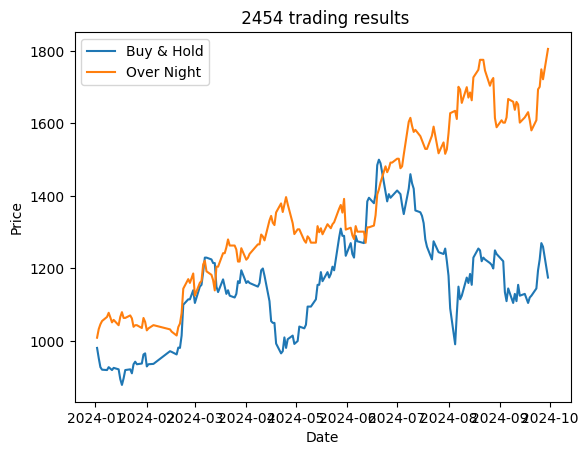

2382 廣達 tw 2024Q1


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.535135,0.525974,0.004345,0.003465,185,81,73,18,13
test,0.553571,0.521739,0.001870,0.000439,56,24,22,7,3


2382 廣達 tw 2024Q2


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.510989,0.491525,0.003269,0.002337,182,58,60,35,29
test,0.360656,0.375000,-0.004102,-0.003884,61,18,30,4,9


2382 廣達 tw 2024Q3


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.566667,0.549020,0.004407,0.003262,180,28,23,74,55
test,0.634921,0.684211,0.008390,0.009149,63,13,6,27,17


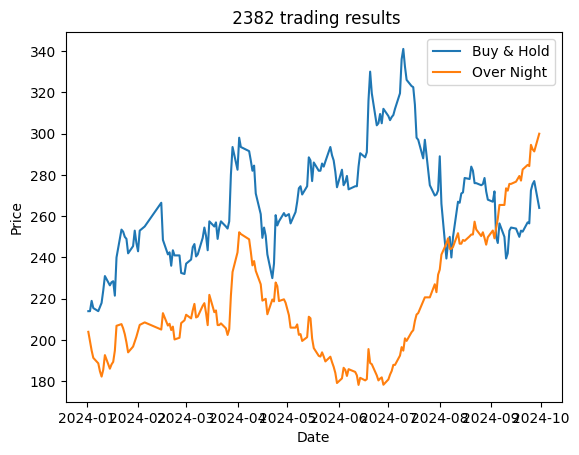

3231 緯創 tw 2024Q1


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.508108,0.488764,0.005249,0.003549,185,87,91,7,0
test,0.428571,0.425926,-0.003028,-0.003603,56,23,31,1,1


3231 緯創 tw 2024Q2


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.472527,0.448276,0.000905,-0.001275,182,65,80,21,16
test,0.393443,0.282609,-0.000425,-0.004506,61,13,33,11,4


3231 緯創 tw 2024Q3


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.572222,0.333333,0.005822,0.00344,180,5,10,98,67
test,0.523810,0.000000,-0.000575,0.00000,63,0,7,33,23


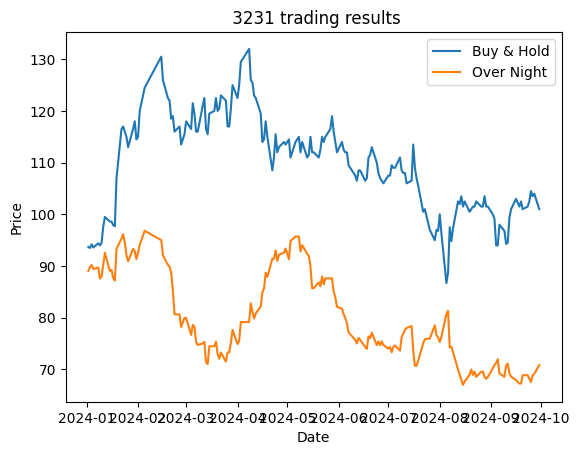

AAPL Apple Inc. us 2024Q1


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.553191,0.606557,0.001287,0.001840,188,74,48,30,36
test,0.475410,0.433333,-0.000280,0.000042,61,13,17,16,15


AAPL Apple Inc. us 2024Q2


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.502674,0.528302,0.000320,0.000622,187,56,50,38,43
test,0.507937,0.468085,-0.000982,-0.000564,63,22,25,10,6


AAPL Apple Inc. us 2024Q3


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.550802,0.560000,0.000890,0.001801,187,56,44,47,40
test,0.546875,0.615385,-0.000777,0.000695,64,24,15,11,14


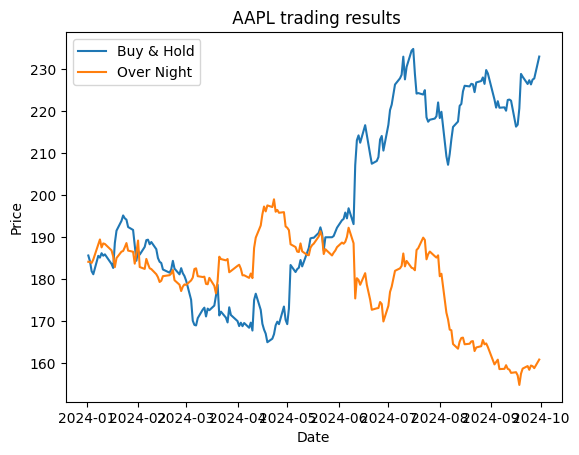

GOOGL Google us 2024Q1


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.558511,0.621951,0.001817,0.003900,188,51,31,54,52
test,0.426230,0.533333,-0.000153,0.001606,61,8,7,18,28


GOOGL Google us 2024Q2


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.529412,0.619048,0.001815,0.004038,187,39,24,60,64
test,0.333333,0.523810,-0.002690,0.000409,63,11,10,10,32


GOOGL Google us 2024Q3


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.481283,0.615385,0.000864,0.003933,187,40,25,50,72
test,0.546875,0.535714,0.000304,-0.002165,64,15,13,20,16


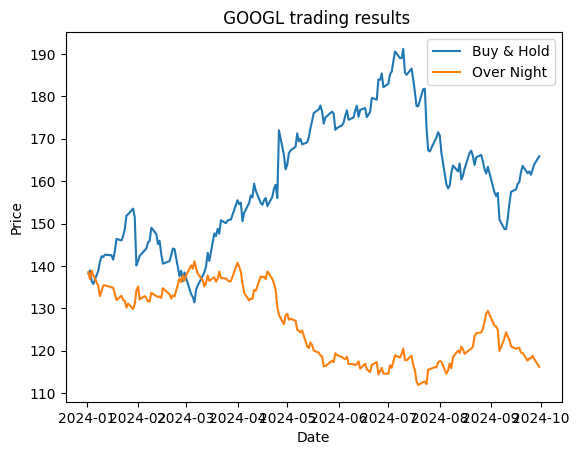

MSFT Microsoft us 2024Q1


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.510638,0.544554,-0.000316,0.000248,188,55,46,41,46
test,0.442623,0.466667,-0.001976,-0.000901,61,21,24,6,10


MSFT Microsoft us 2024Q2


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.486631,0.506757,0.000134,0.000184,187,75,73,16,23
test,0.619048,0.640000,0.000180,0.000144,63,32,18,7,6


MSFT Microsoft us 2024Q3


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.524064,0.557823,0.000068,0.000530,187,82,65,16,24
test,0.500000,0.487179,0.000521,-0.000781,64,19,20,13,12


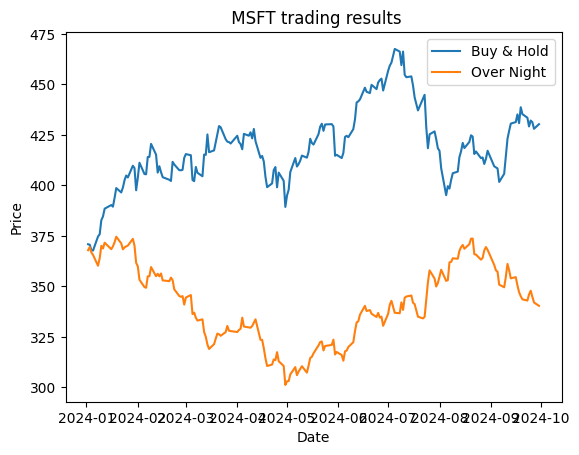

AMZN Amazon inc. us 2024Q1


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.473404,0.522727,-0.001166,-0.000368,188,46,42,43,57
test,0.491803,0.571429,0.000068,0.001584,61,20,15,10,16


AMZN Amazon inc. us 2024Q2


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.489247,0.530769,-0.000625,0.000131,186,69,61,22,34
test,0.507937,0.518519,-0.000320,-0.000309,63,28,26,4,5


AMZN Amazon inc. us 2024Q3


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.486631,0.547009,-0.000011,0.001006,187,64,53,27,43
test,0.421875,0.380952,-0.001627,-0.002462,64,16,26,11,11


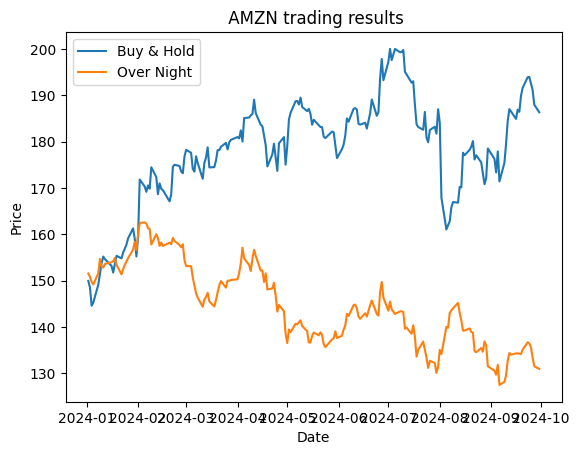

TSLA Tesla us 2024Q1


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.515957,0.573333,0.001543,0.003246,188,43,32,54,59
test,0.508197,0.363636,0.000652,-0.002504,61,4,7,27,23


TSLA Tesla us 2024Q2


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.534759,0.545455,0.001857,0.001856,187,30,25,70,62
test,0.492063,0.250000,-0.002322,-0.009307,63,1,3,30,29


TSLA Tesla us 2024Q3


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.524064,0.531250,0.001229,0.003411,187,17,15,81,74
test,0.578125,0.764706,0.002606,0.009801,64,13,4,24,23


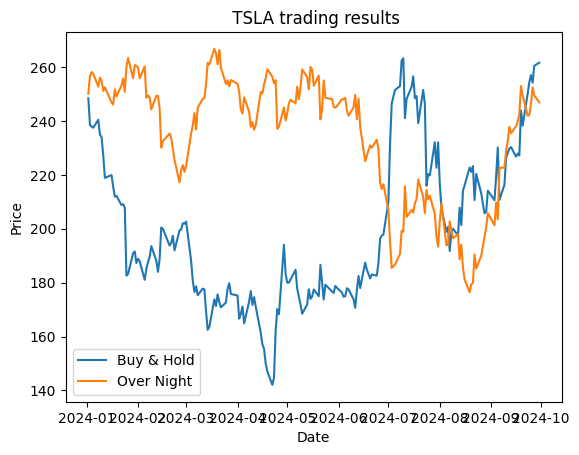

NVDA Nvidia us 2024Q1


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.526596,0.528571,0.002075,0.001857,188,74,66,25,23
test,0.508197,0.560000,-0.000819,0.001657,61,28,22,3,8


NVDA Nvidia us 2024Q2


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.529412,0.542857,0.001102,0.001390,187,76,64,23,24
test,0.476190,0.521739,-0.001527,-0.000959,63,24,22,6,11


NVDA Nvidia us 2024Q3


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
train,0.497326,0.549180,-0.000142,0.001182,187,67,55,26,39
test,0.515625,0.513514,-0.001542,-0.002371,64,19,18,14,13


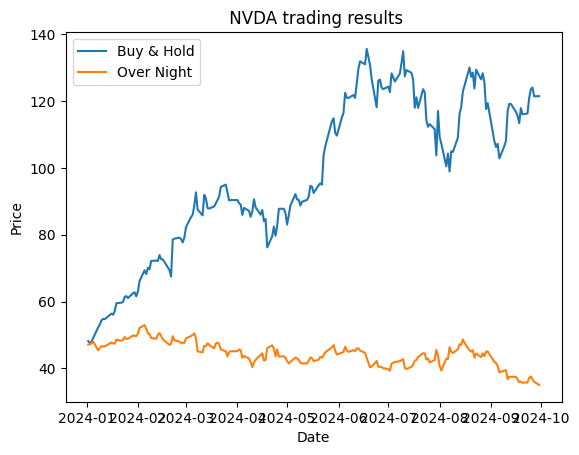

,accuracy,precision,ev,precision_ev
平均值,0.50194,0.480779,0.000821,0.000757
最終平均值,0.50194,0.480779,0.000821,0.000757


In [7]:
from factor import Factor

avgs = pd.DataFrame()
def runAll(i, avgs):
    stock_results = []
    index = []
    for stock in data:
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = Factor(env, i)
            eval_module.generate_factors(llm)
            eval_module.expand_factors(llm_factors=llm)
            train_datarange, test_datarange = eval_module.split_exp()

            mode = 1
            df = eval_module.run_taining(mode, train_datarange, test_datarange)
            display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']])

            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            
            
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])

        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        plt.title(f" {env['stock_id']} trading results")
        plt.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        plt.plot(dplot, list_stag_balance, label="Over Night")  # orange

        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.show()
            
    df_stock_results = pd.DataFrame(stock_results, index=index)
    selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']  # 替換為您需要的欄位名稱
    df_selected = df_stock_results.loc[:, selected_columns]

    columns_to_average = ['accuracy', 'precision', 'ev', 'precision_ev']
    averages = df_selected[columns_to_average].replace('%', '', regex=True).astype(float).mean()
    average_row = pd.DataFrame(averages).T
    average_row.index = ['平均值']

    avgs = pd.concat([avgs, average_row])
    
    df_selected_with_avg = pd.concat([df_selected, average_row])
    df_selected_with_avg['accuracy'] = df_selected_with_avg['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
    df_selected_with_avg['precision'] = df_selected_with_avg['precision'].apply(lambda x: f"{x * 100:.2f}%")
    return avgs
    # display(df_selected_with_avg)

for i in range(1, 2):
    print(i)
    avgs = runAll(i, avgs)

# 計算最後一列的平均值
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['最終平均值']

# 將最終平均值添加到 avgs
avgs = pd.concat([avgs, final_average_row])

display(avgs)

# Method 2

1


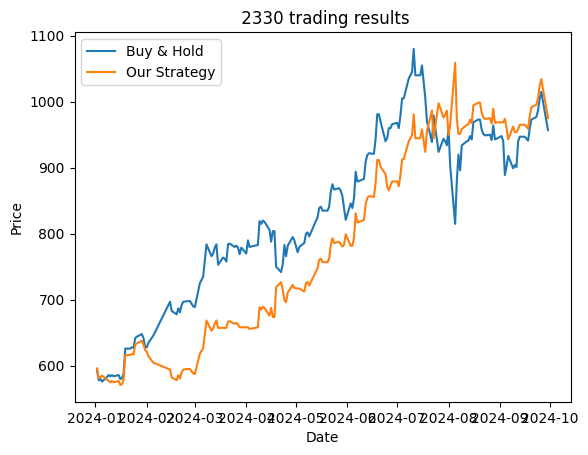

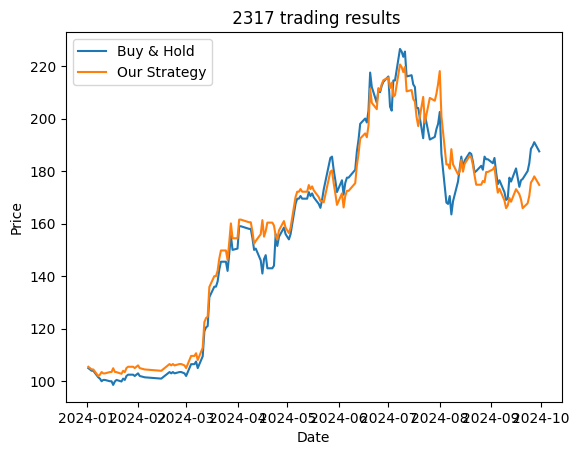

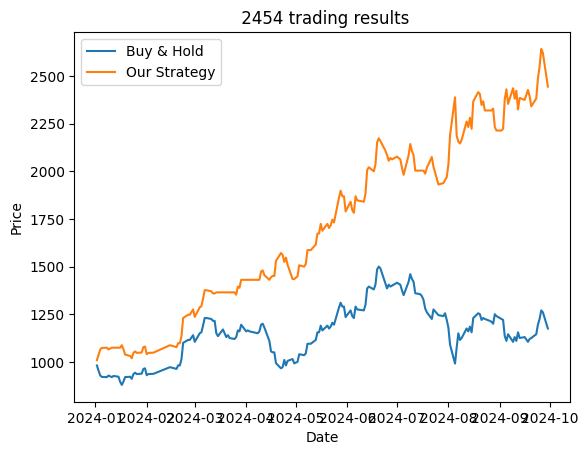

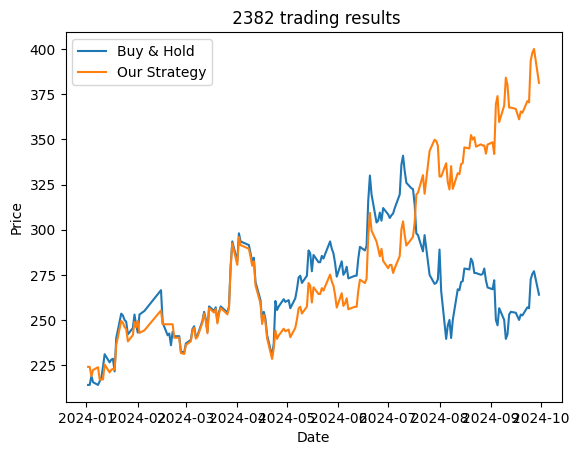

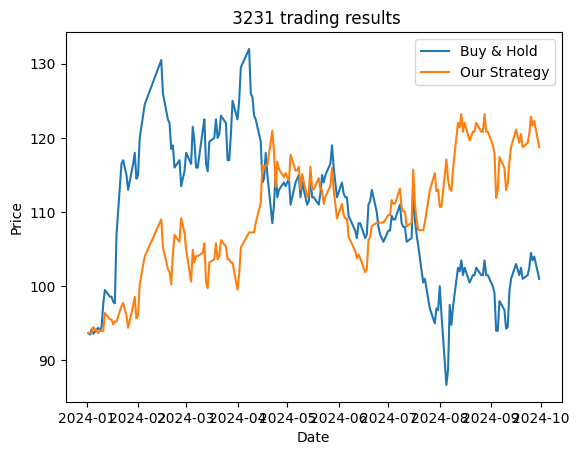

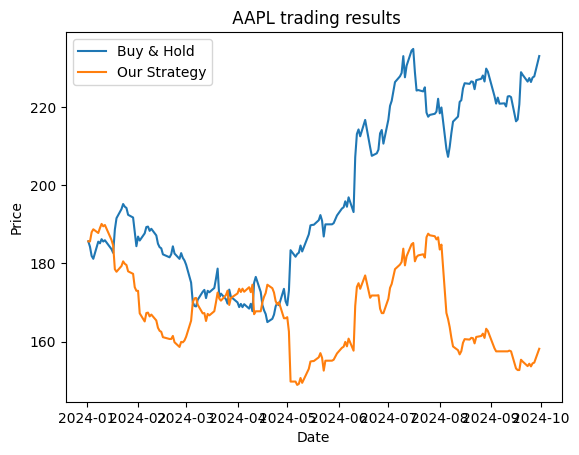

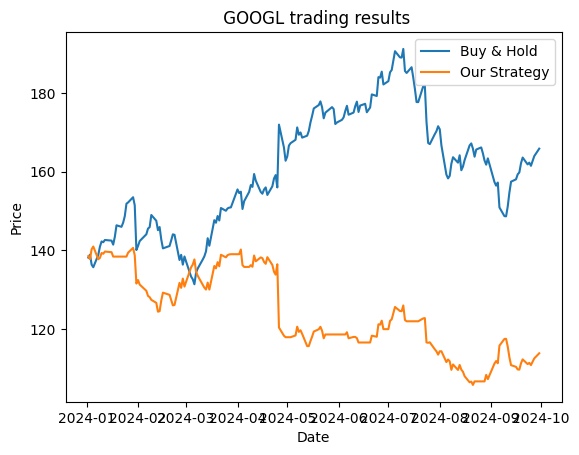

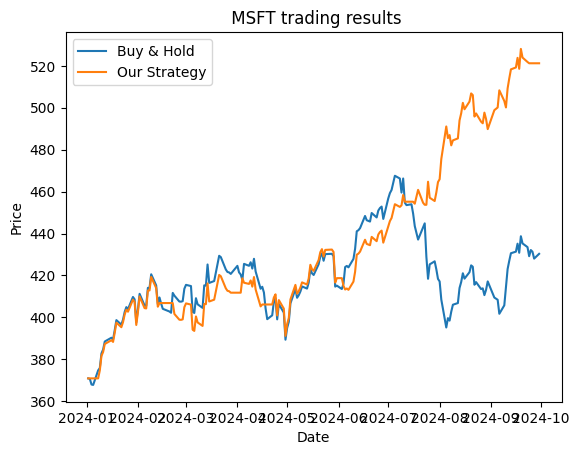

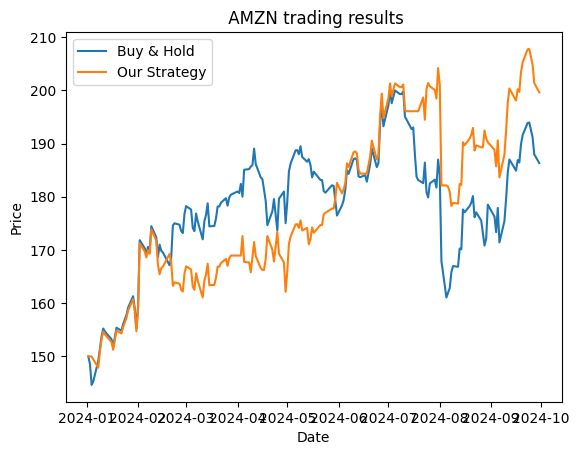

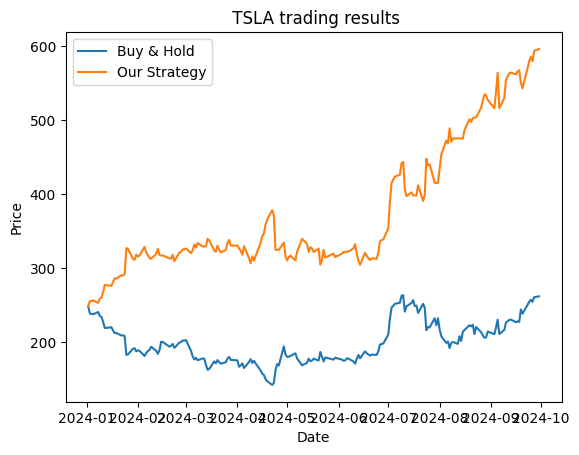

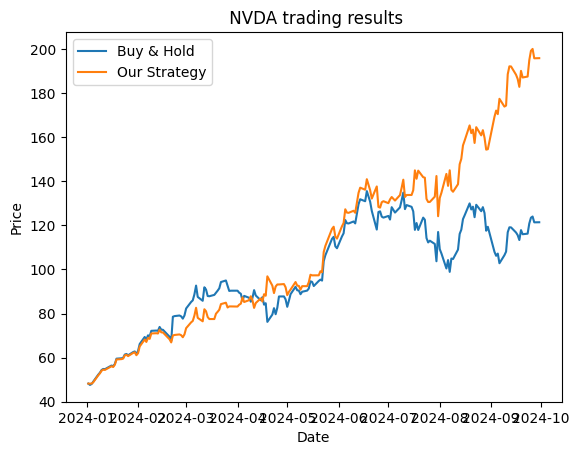

2


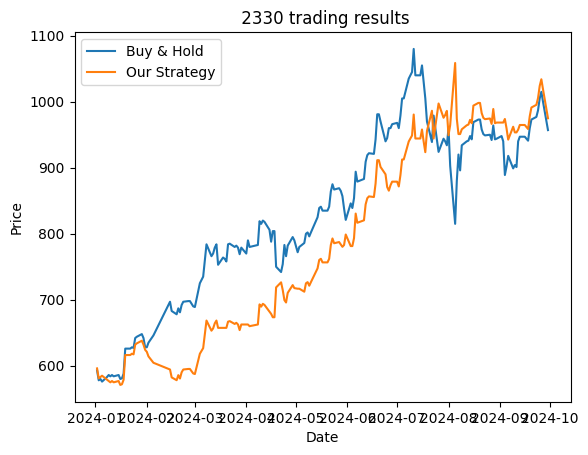

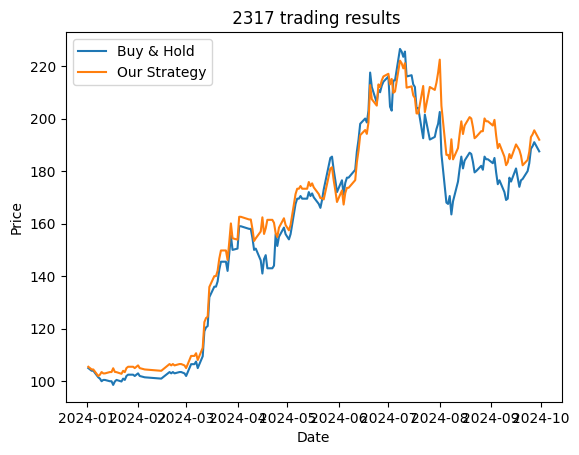

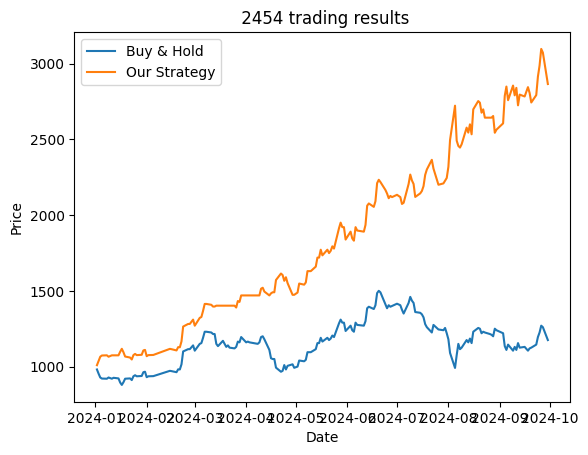

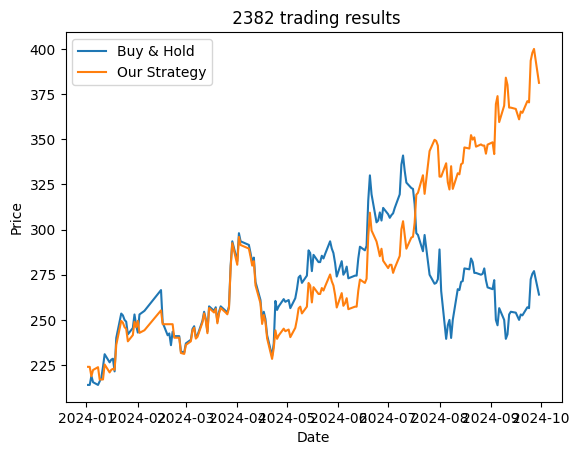

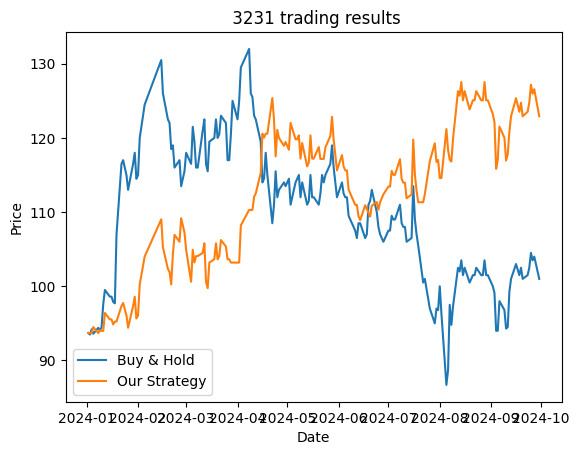

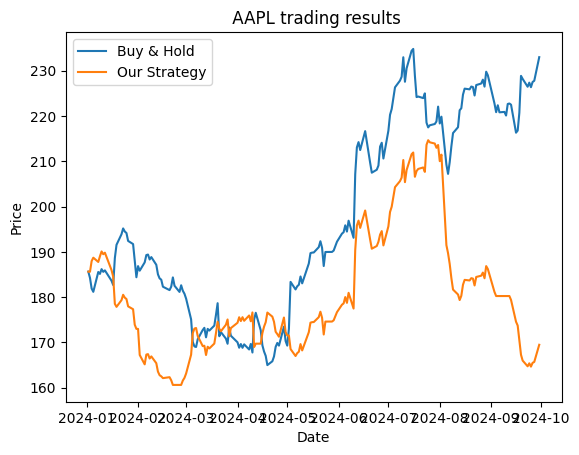

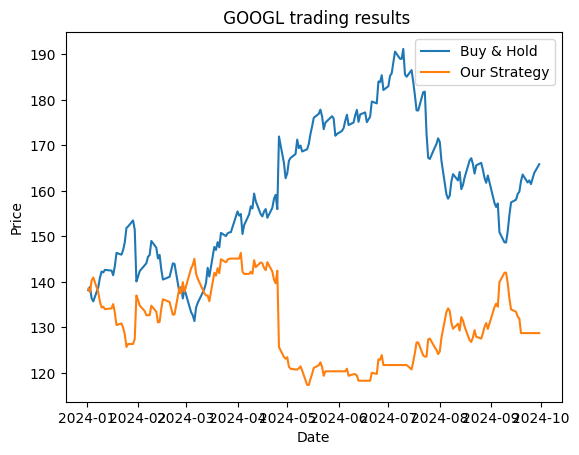

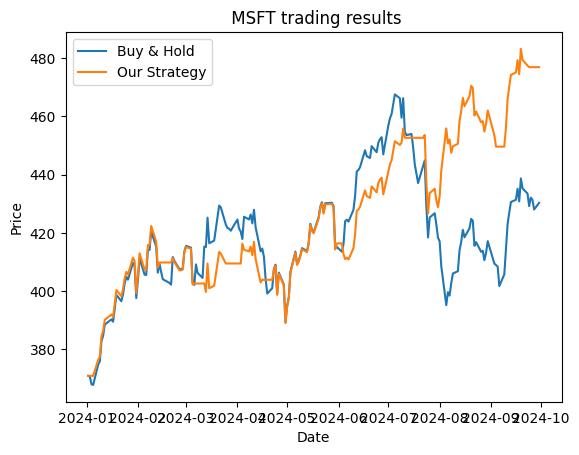

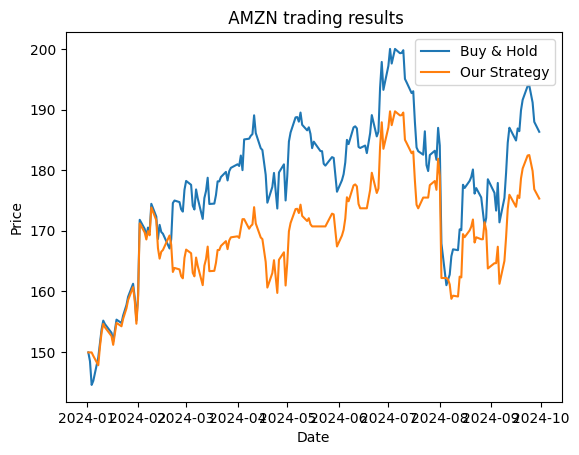

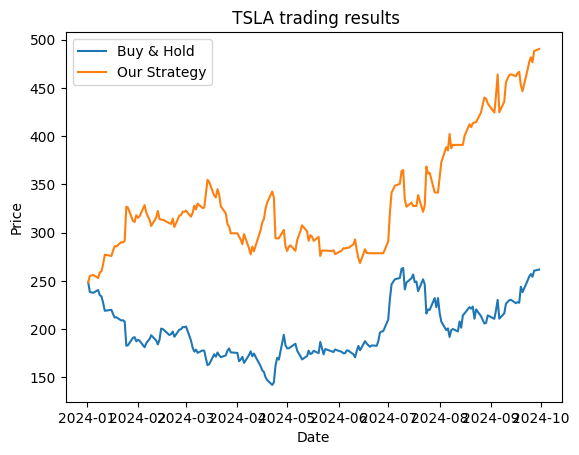

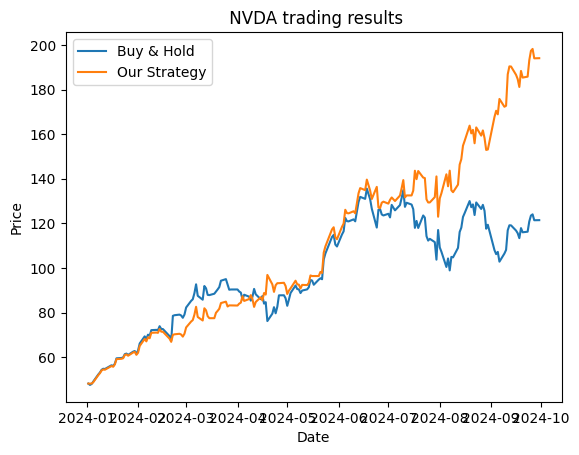

3


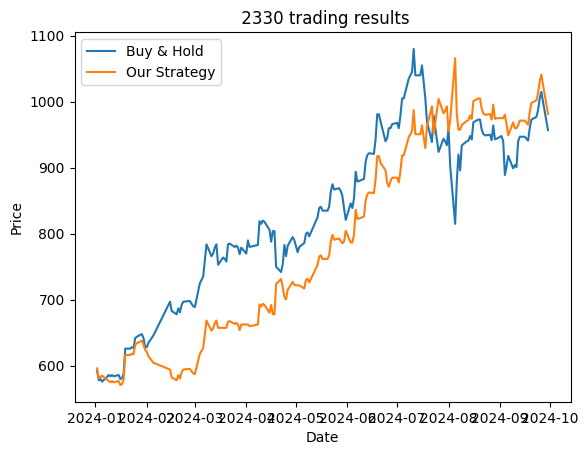

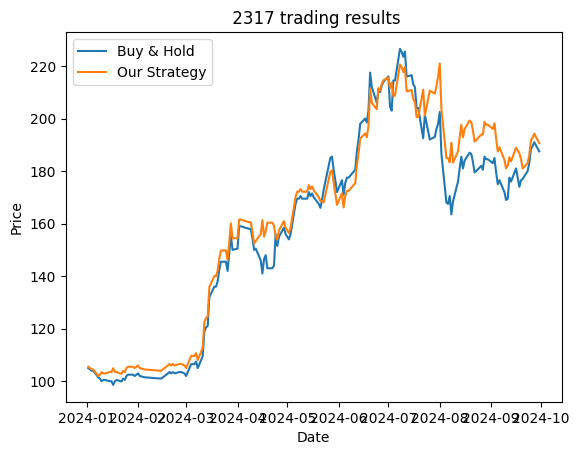

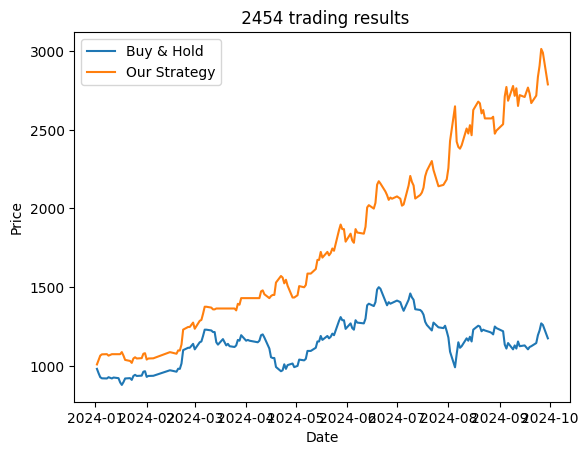

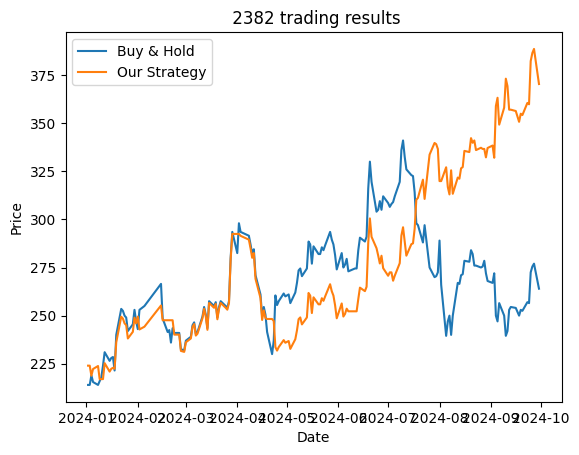

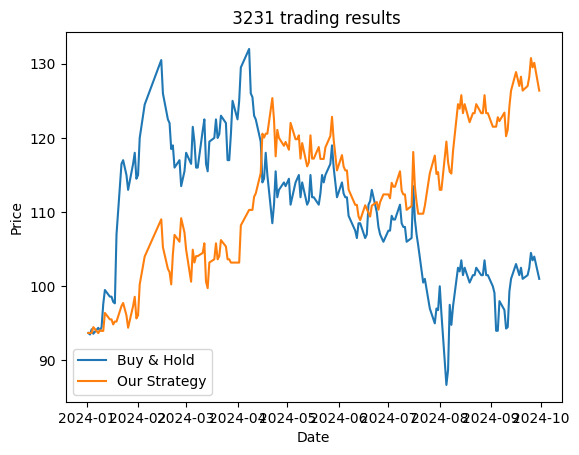

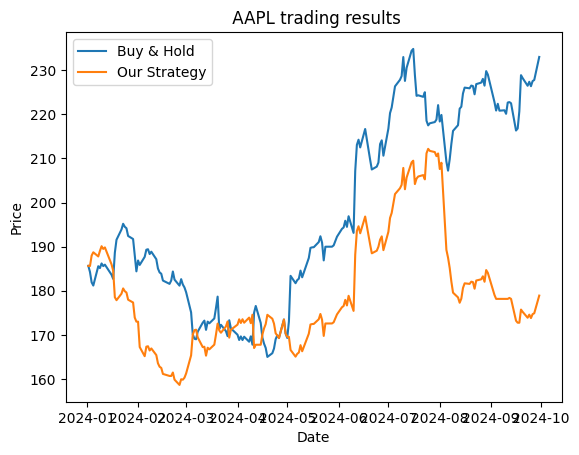

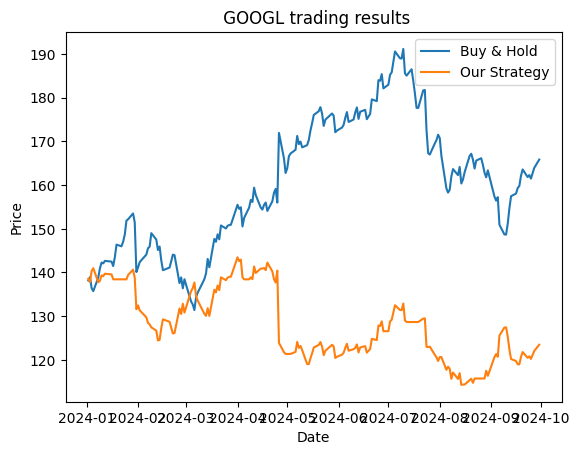

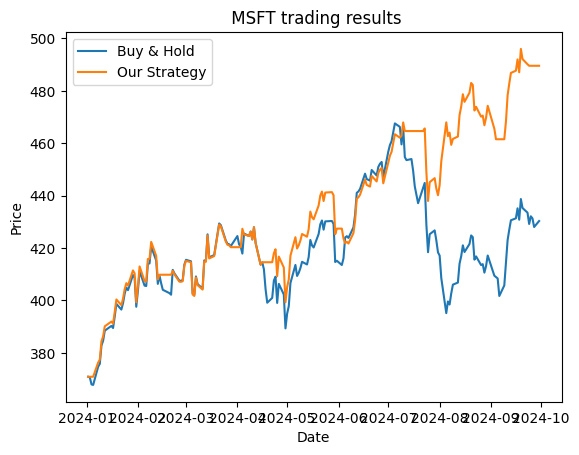

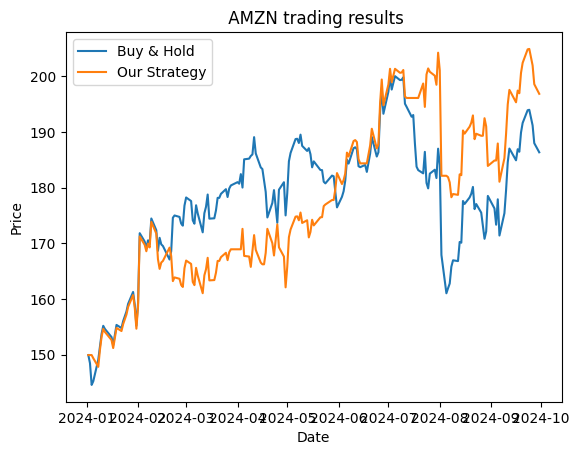

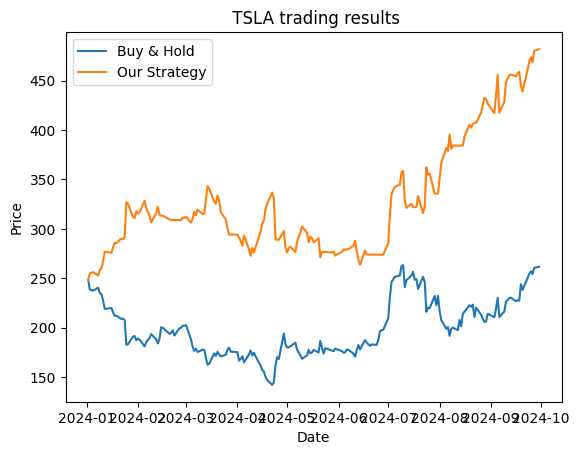

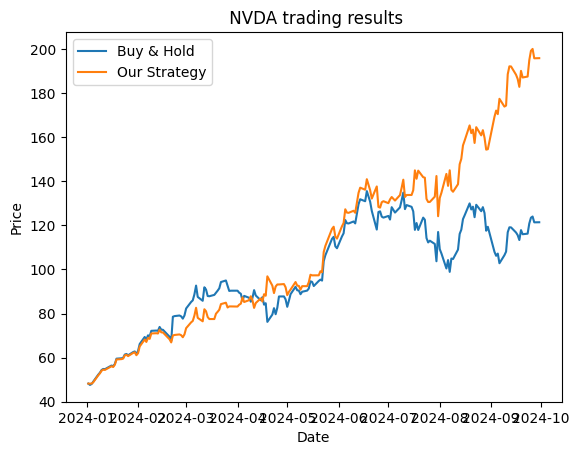

4


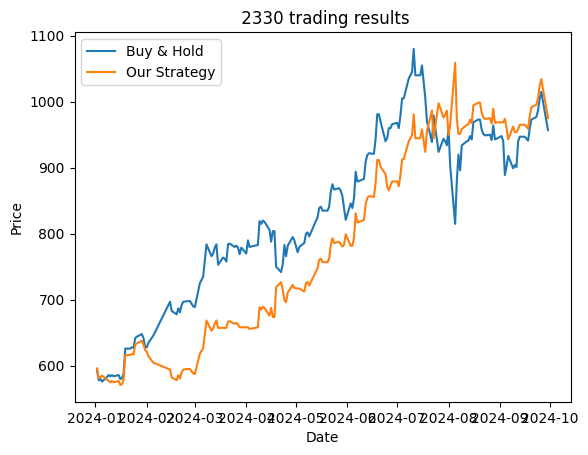

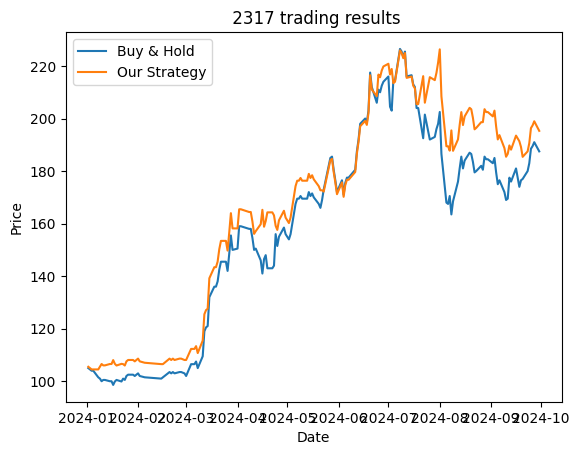

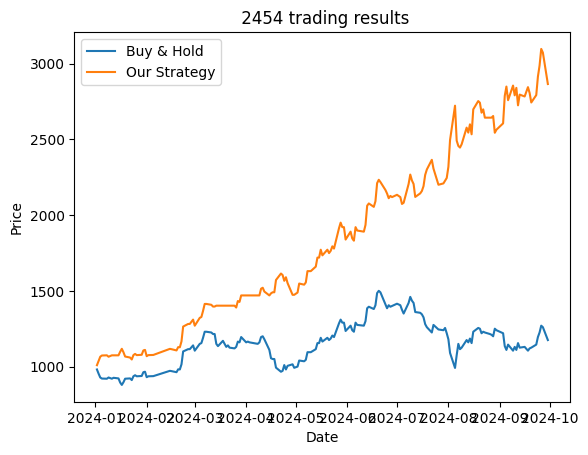

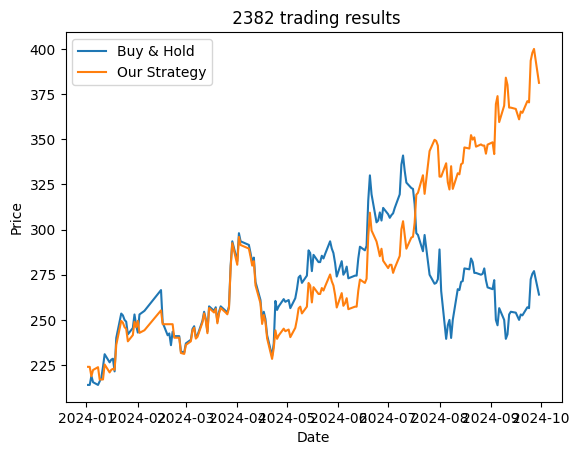

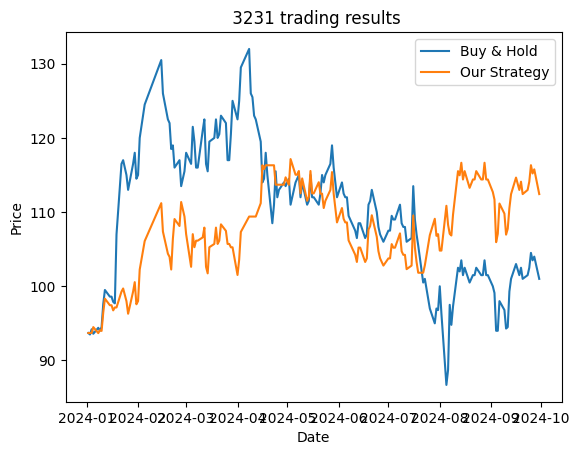

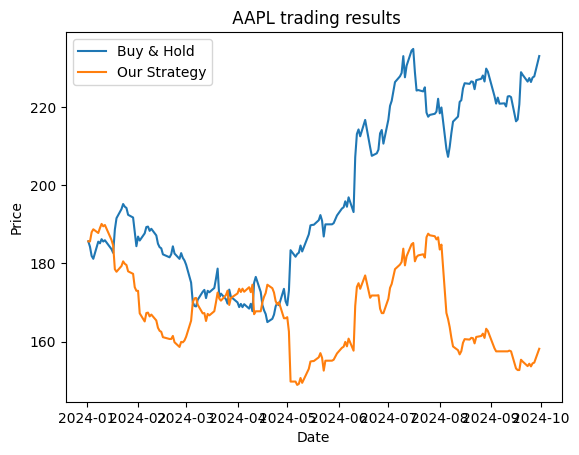

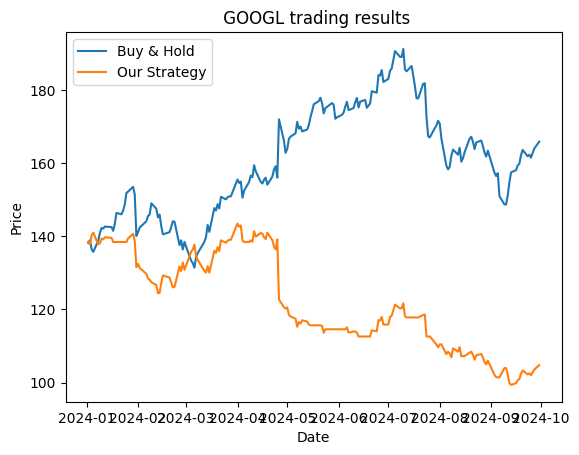

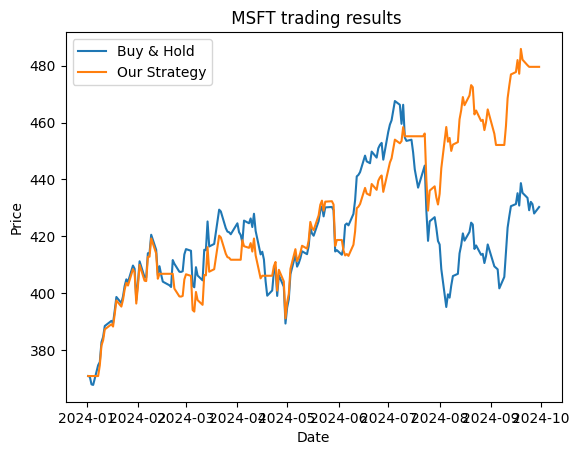

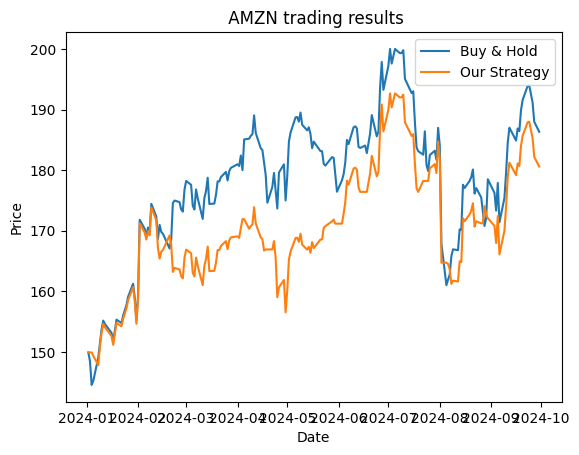

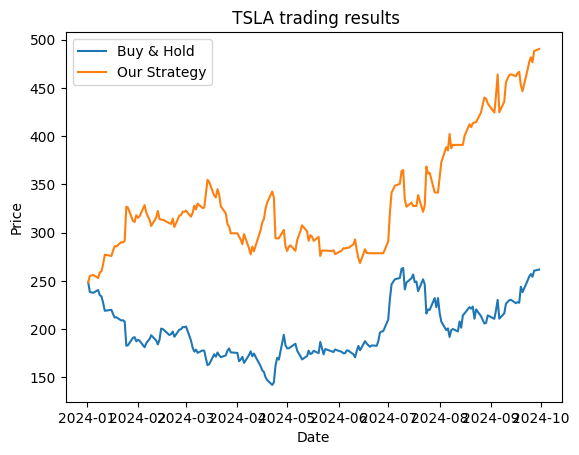

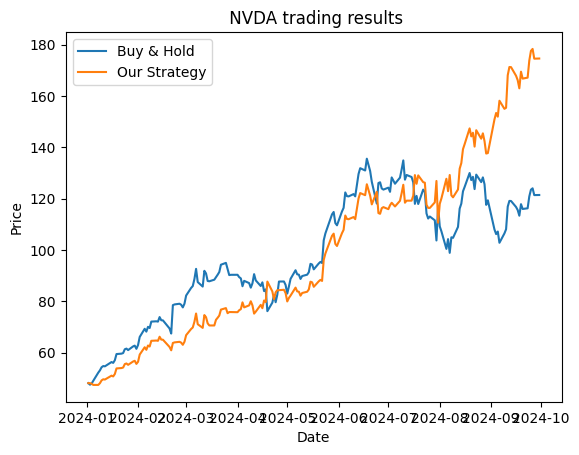

5


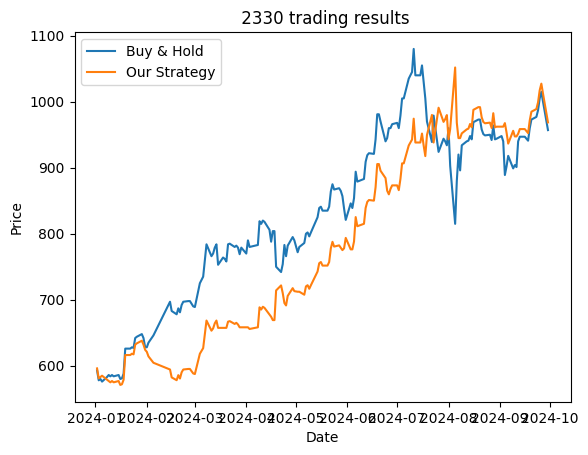

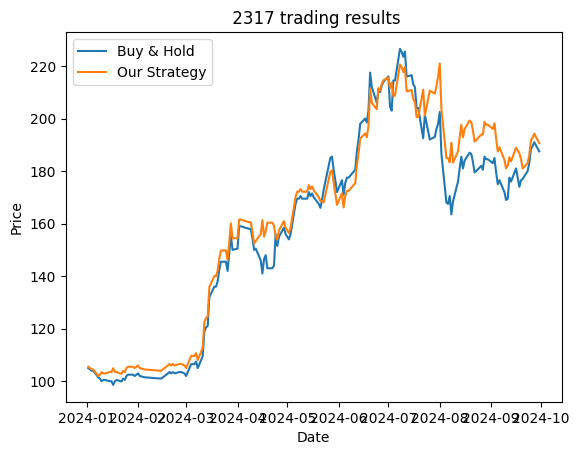

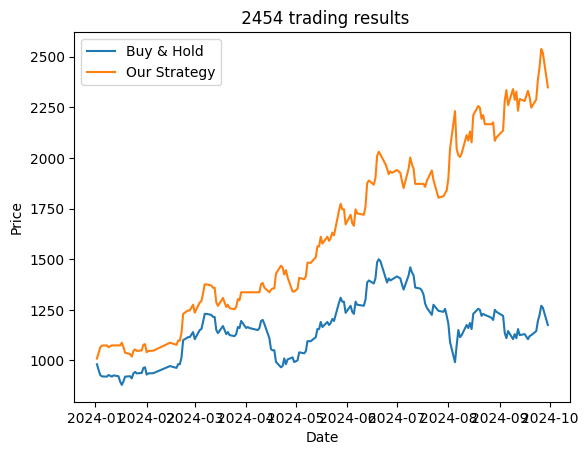

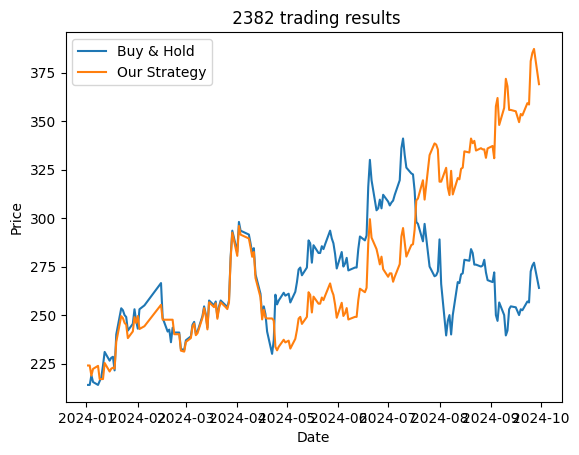

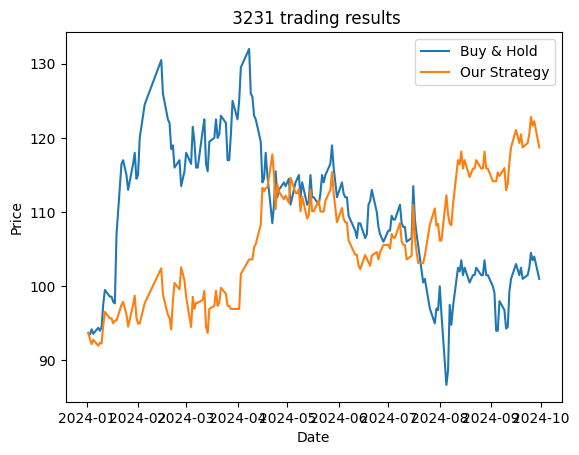

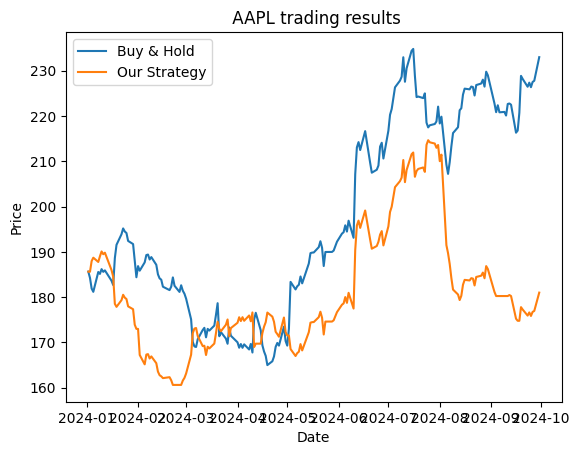

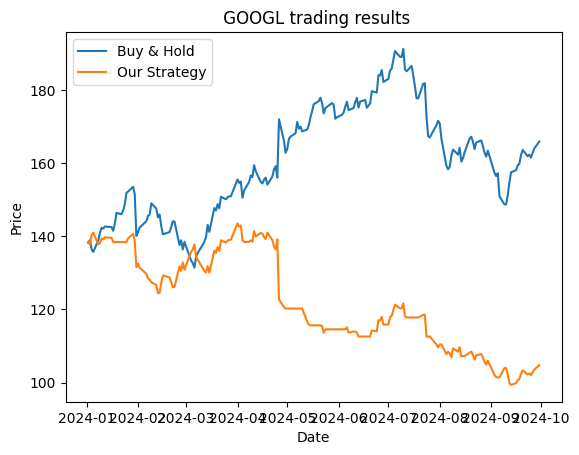

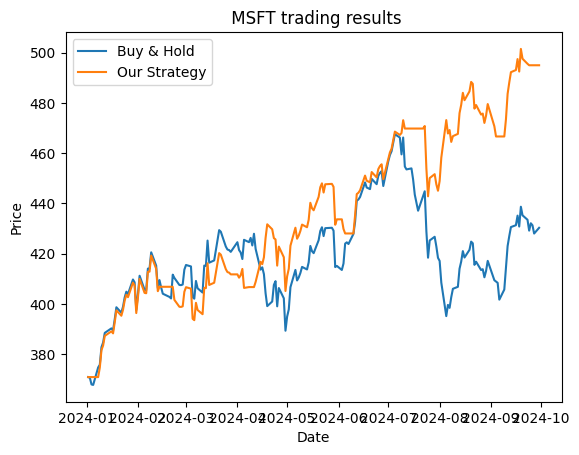

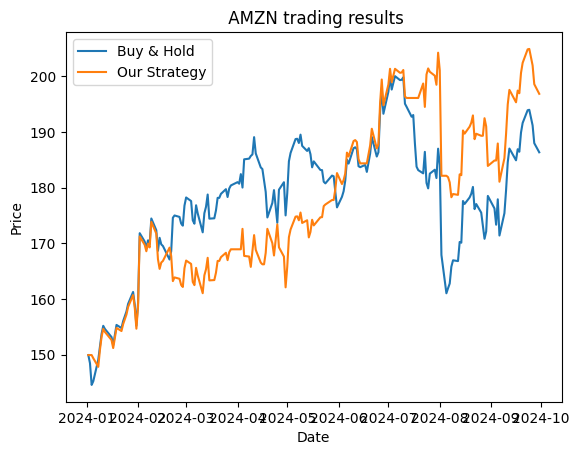

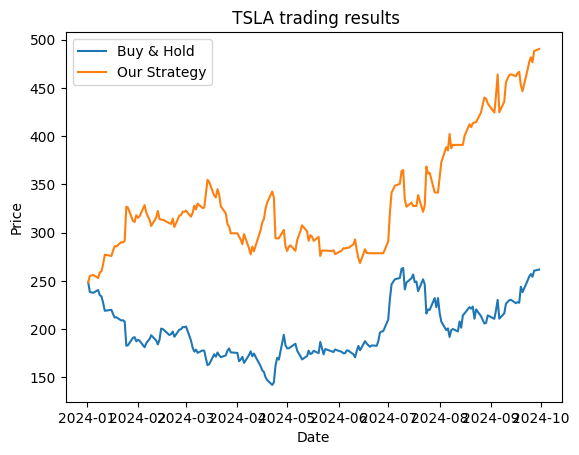

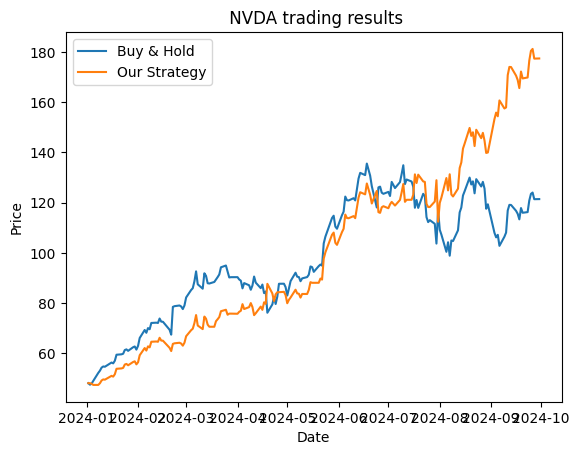

6


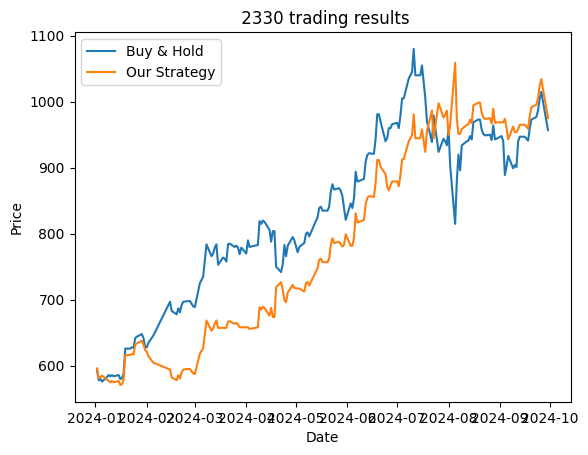

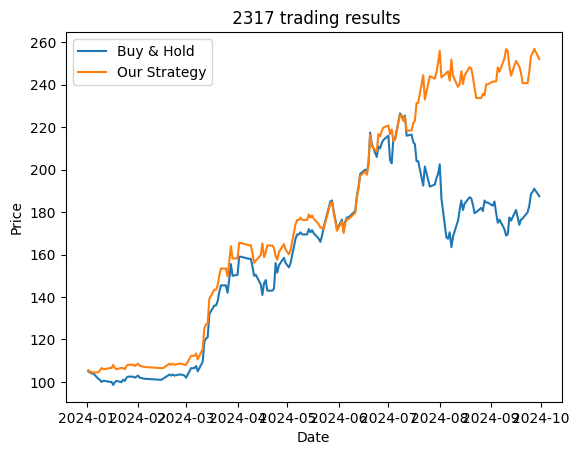

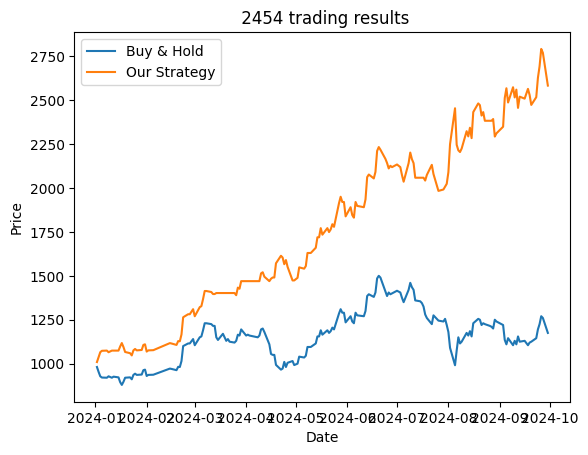

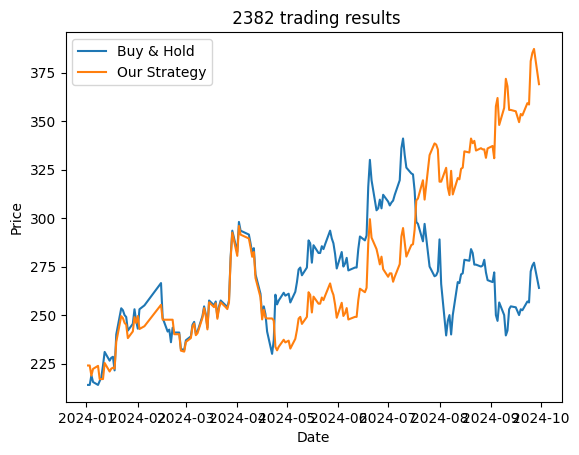

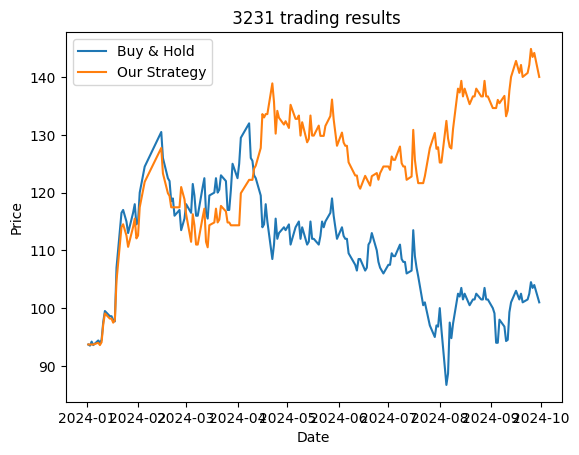

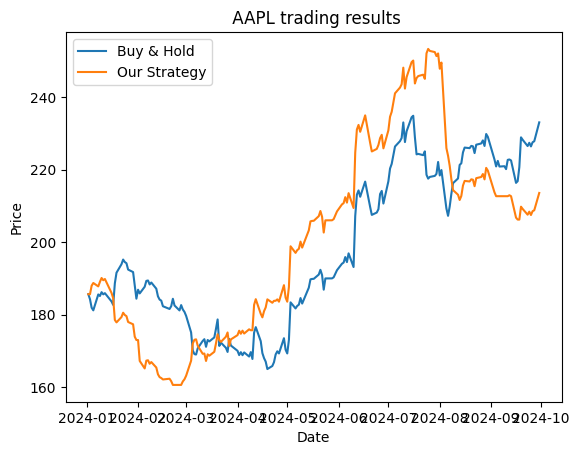

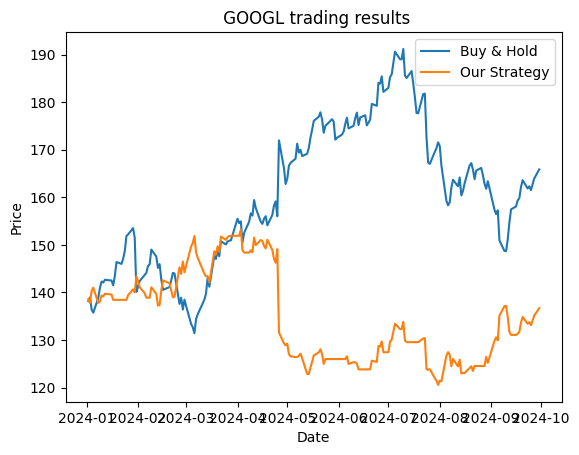

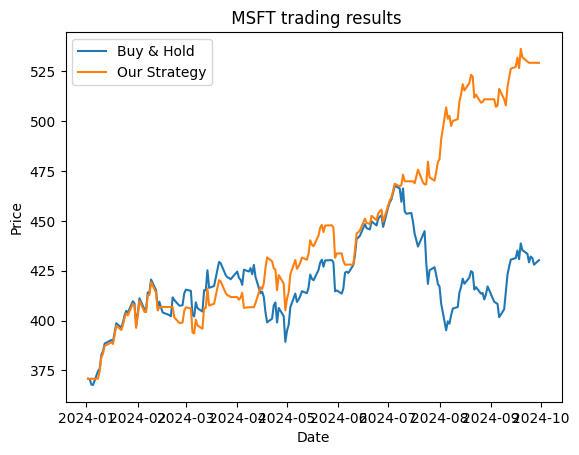

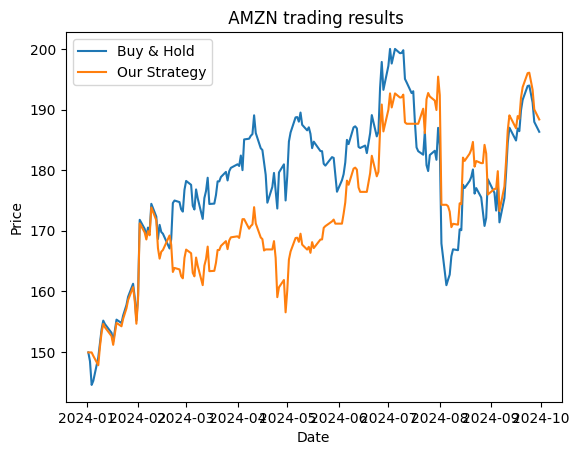

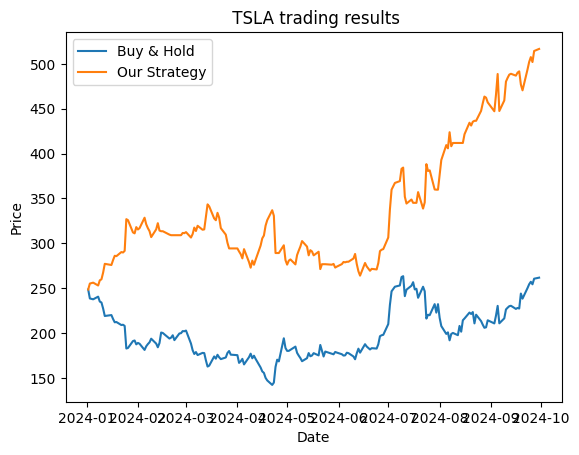

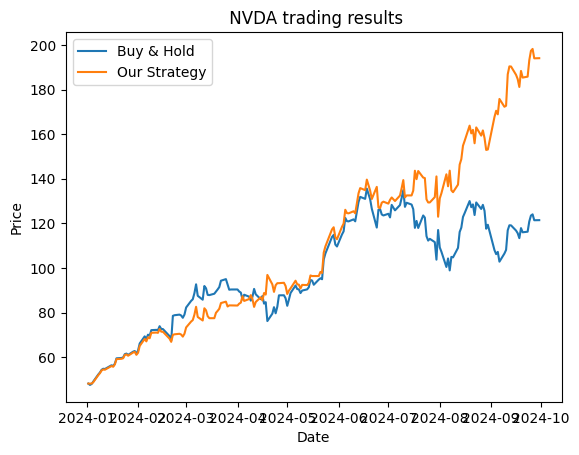

7


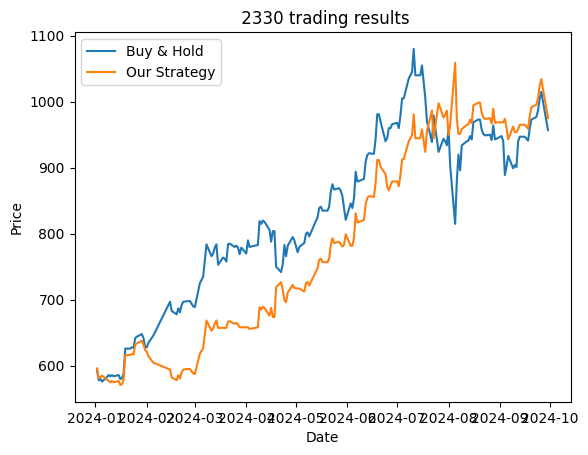

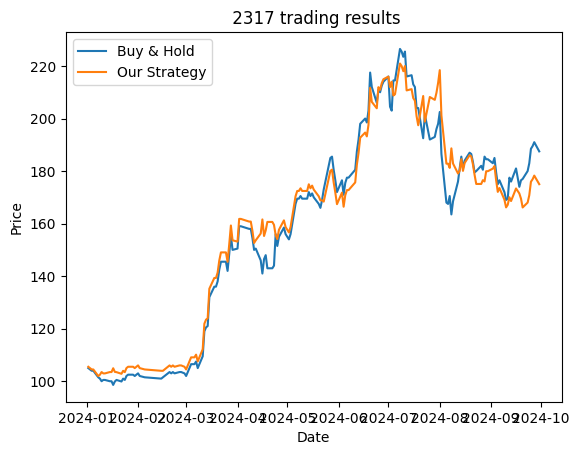

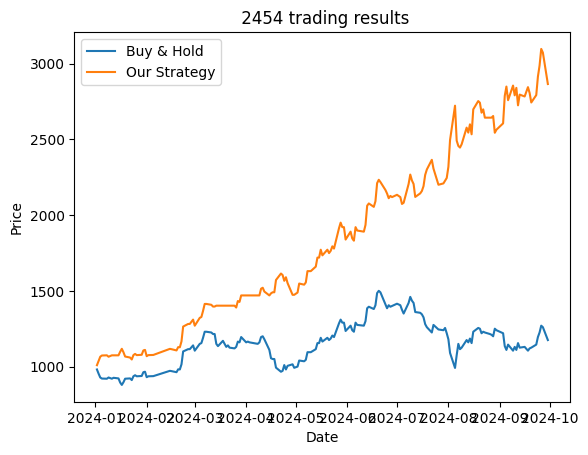

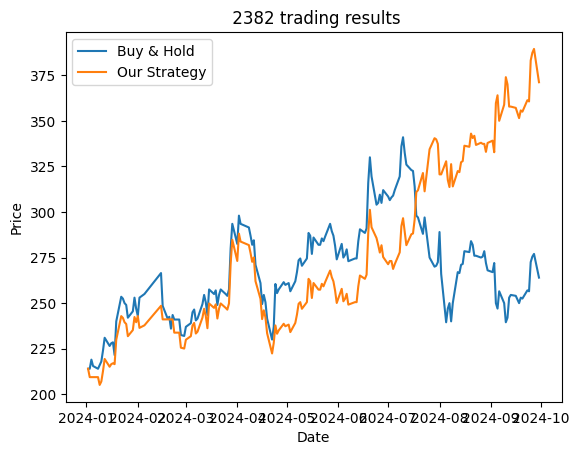

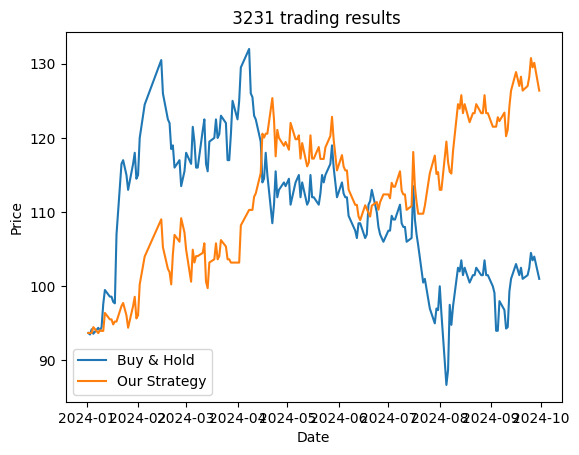

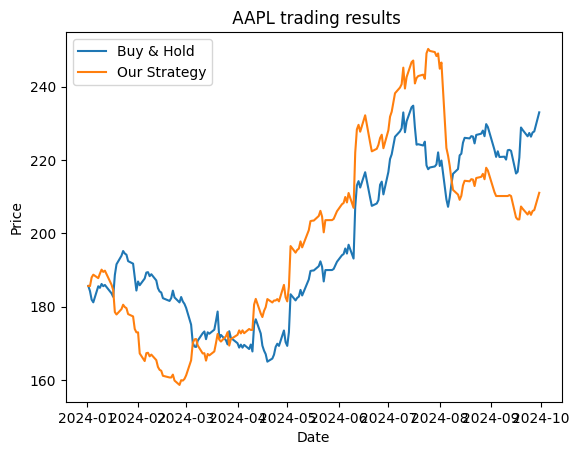

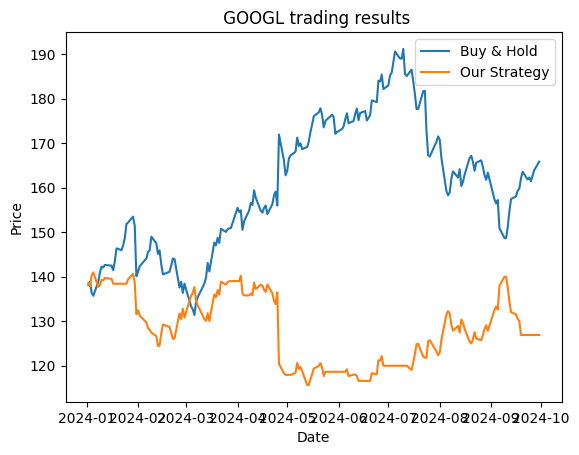

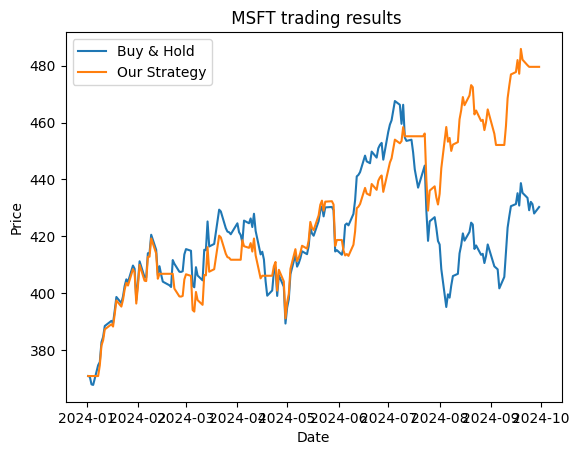

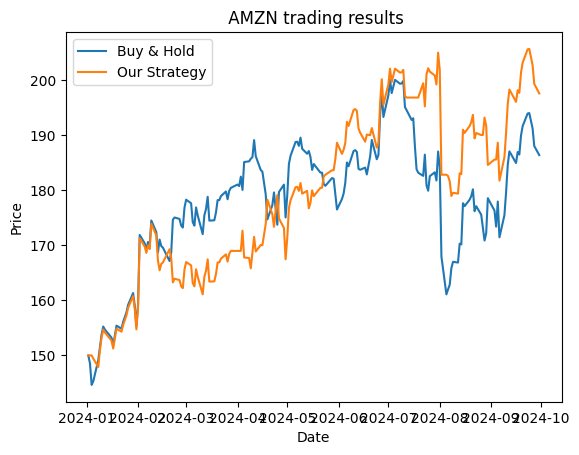

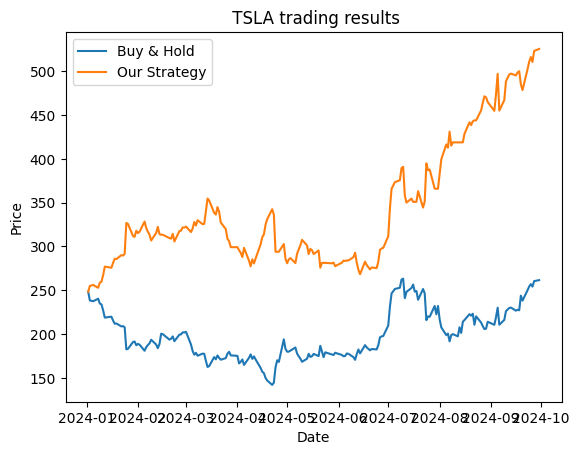

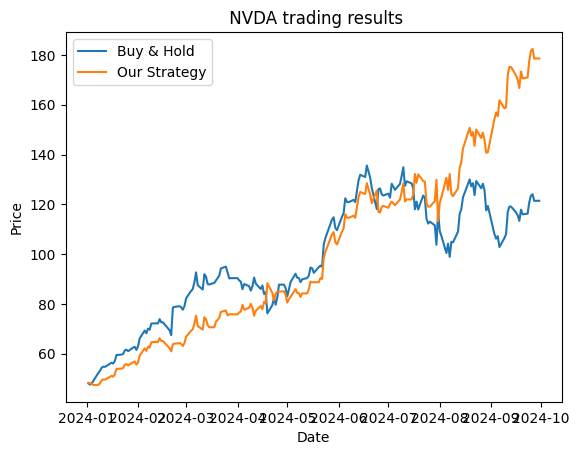

8


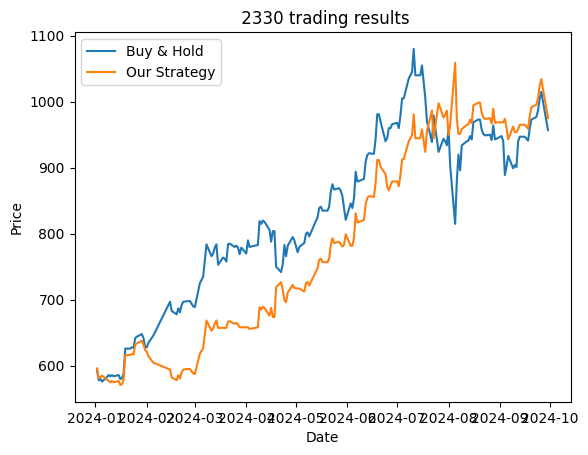

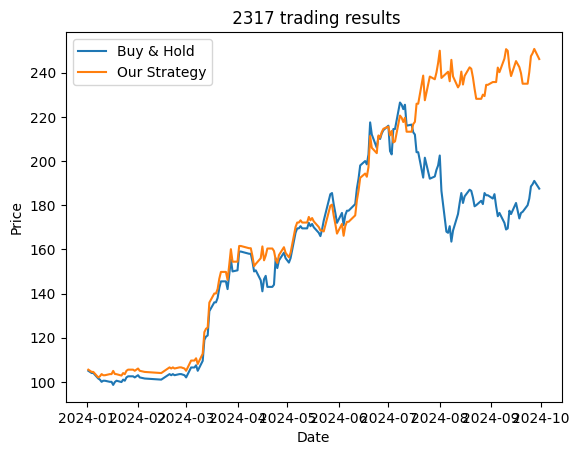

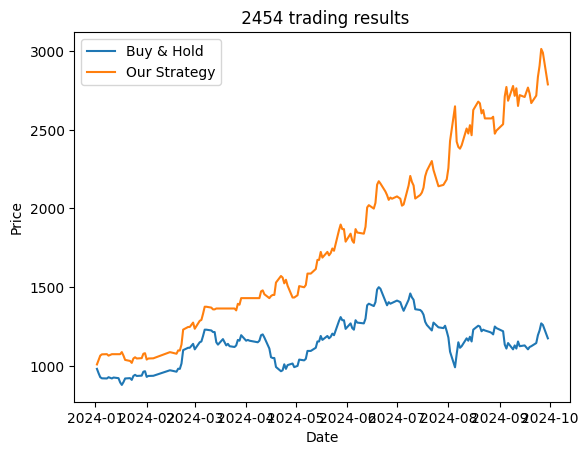

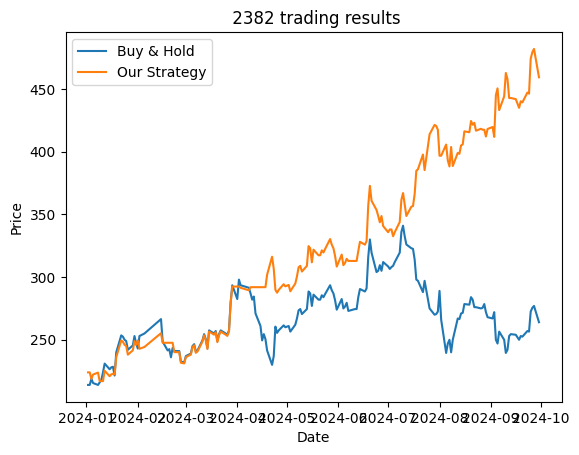

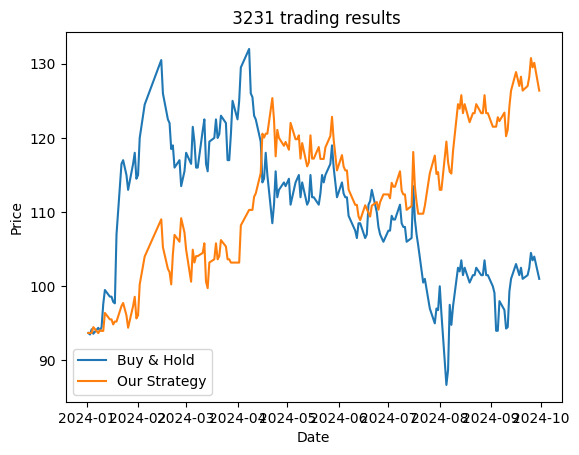

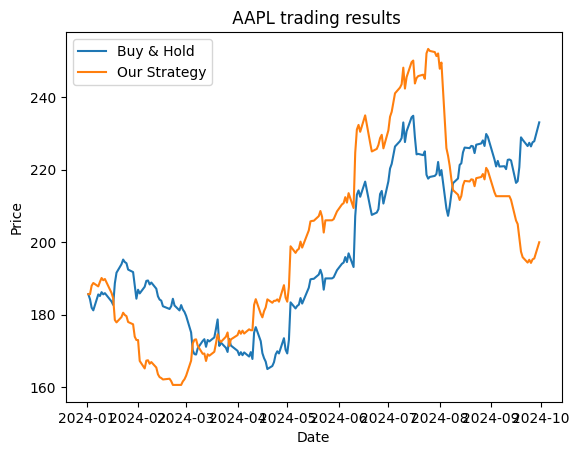

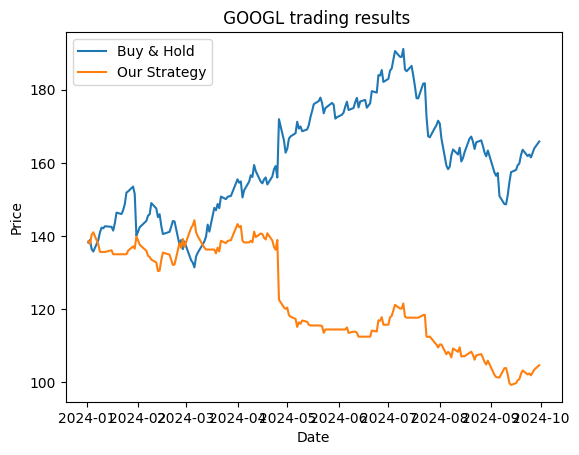

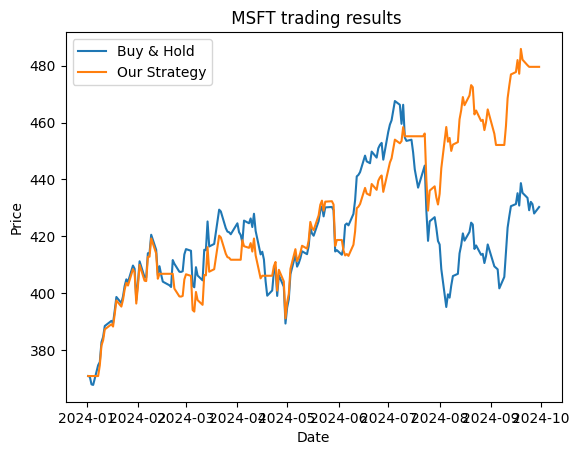

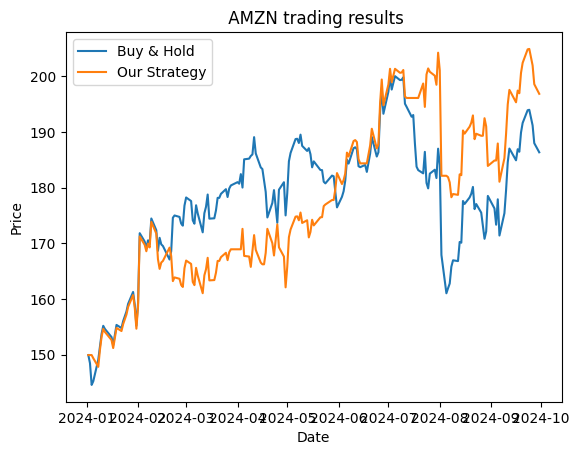

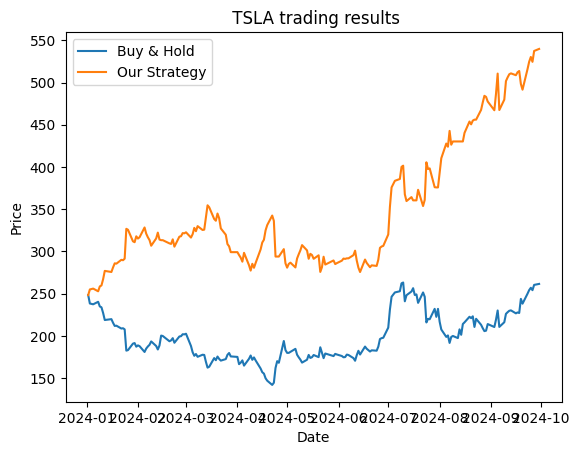

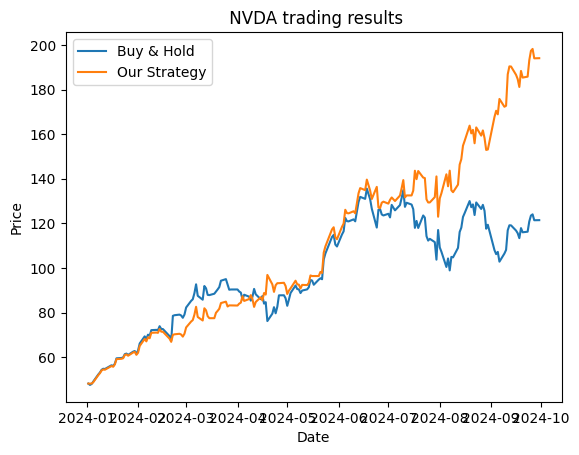

9


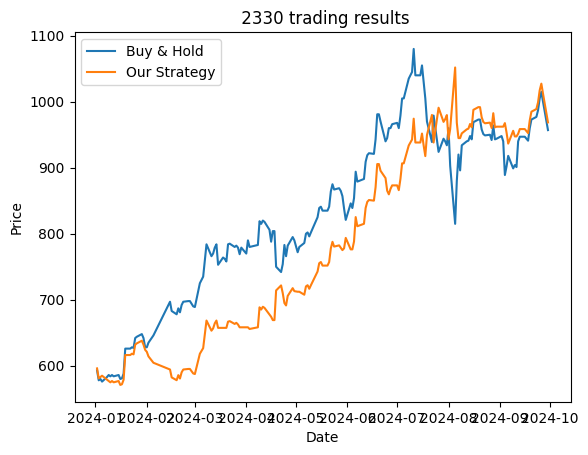

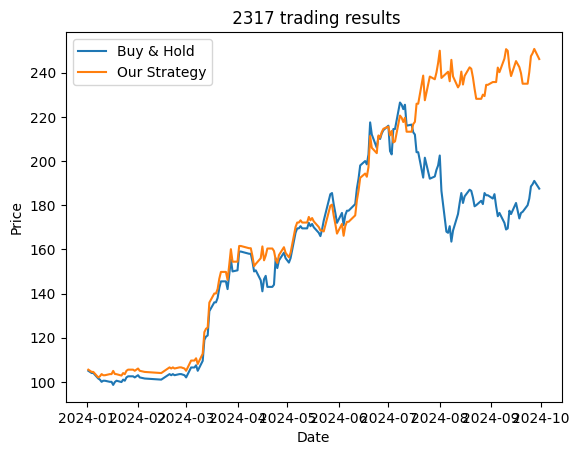

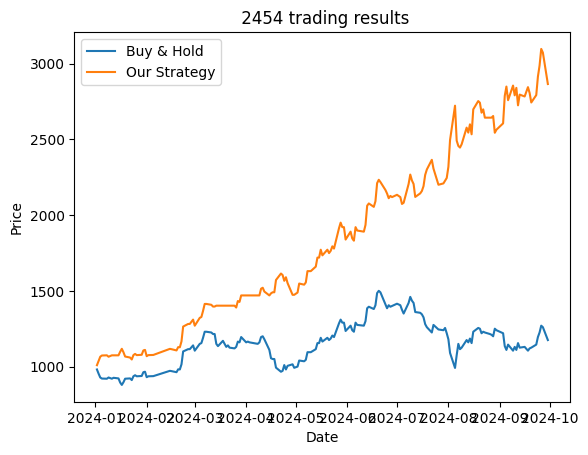

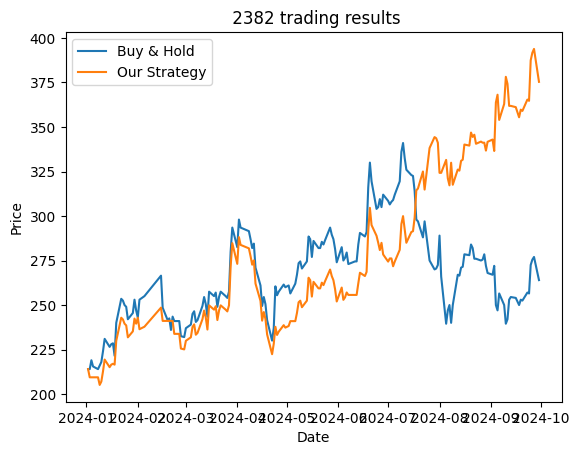

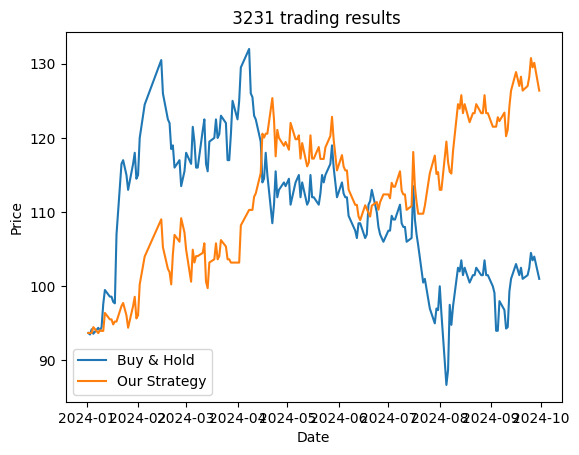

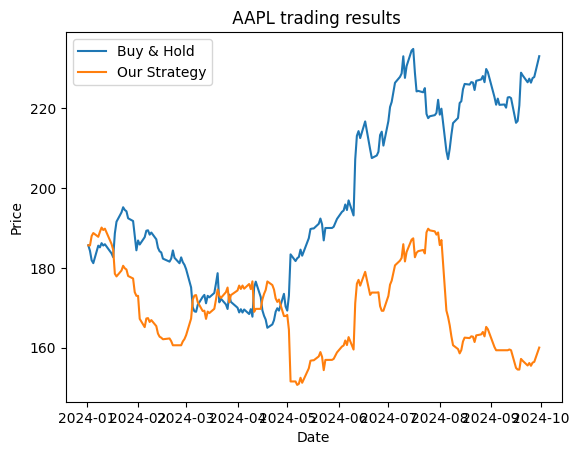

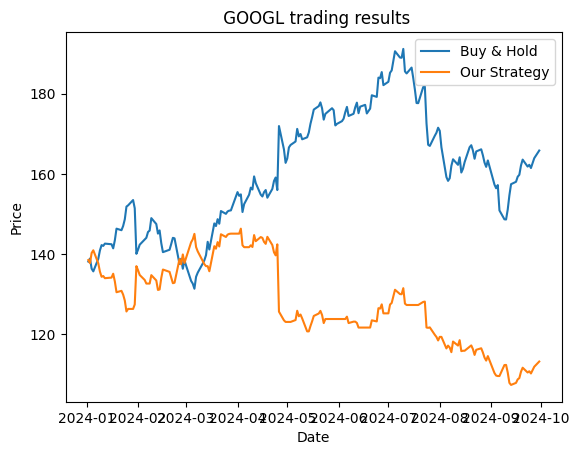

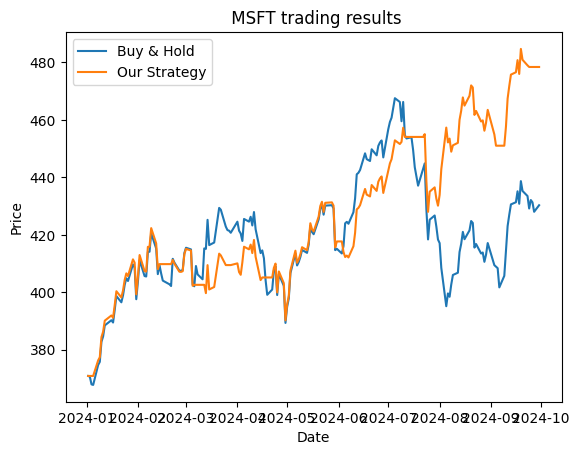

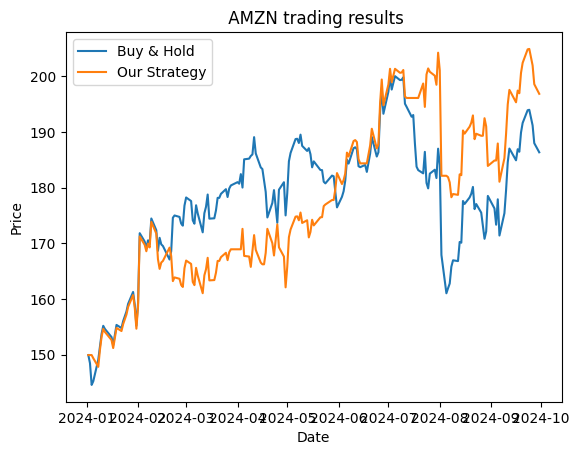

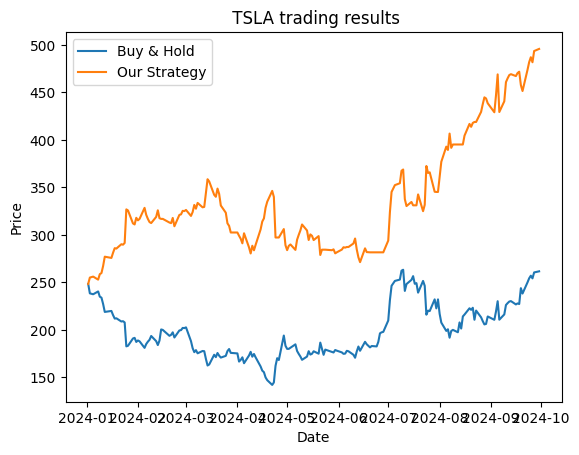

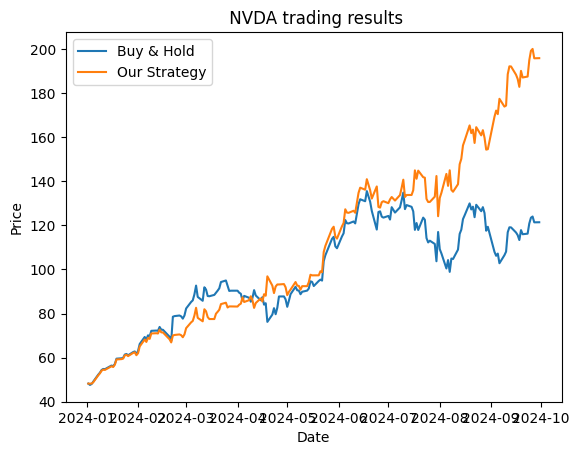

10


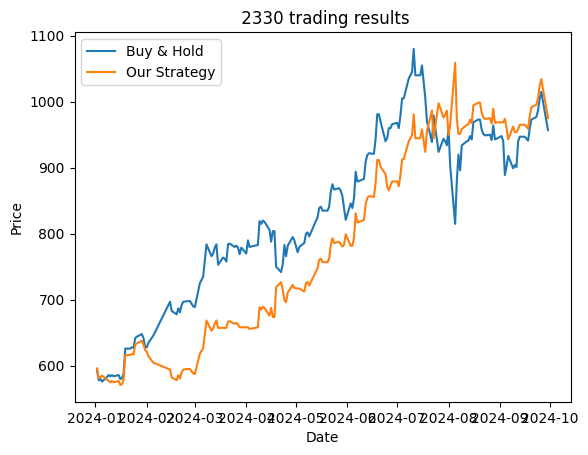

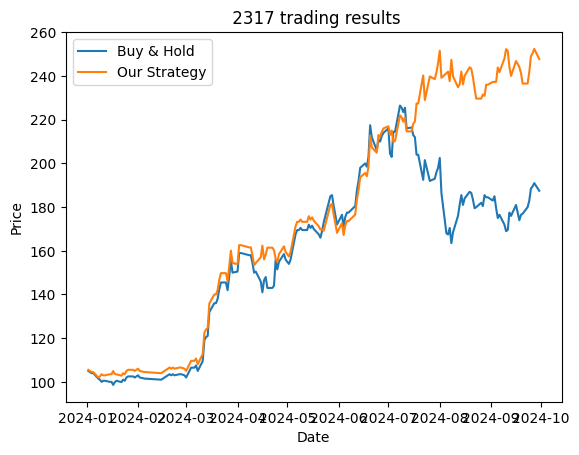

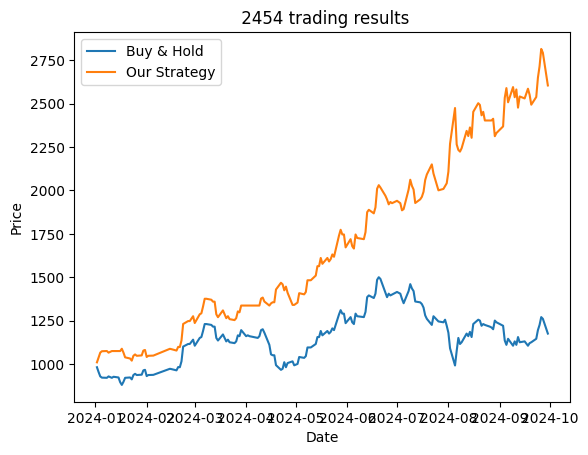

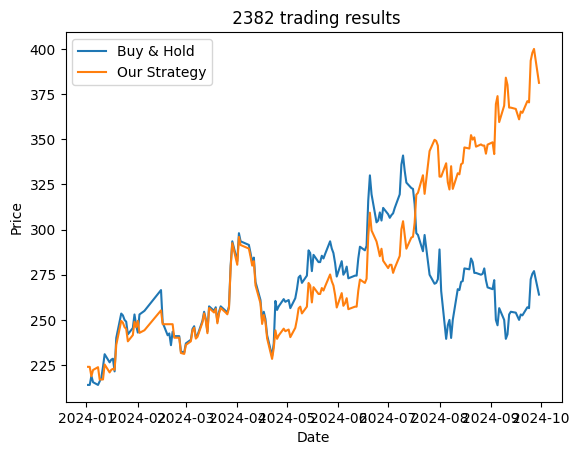

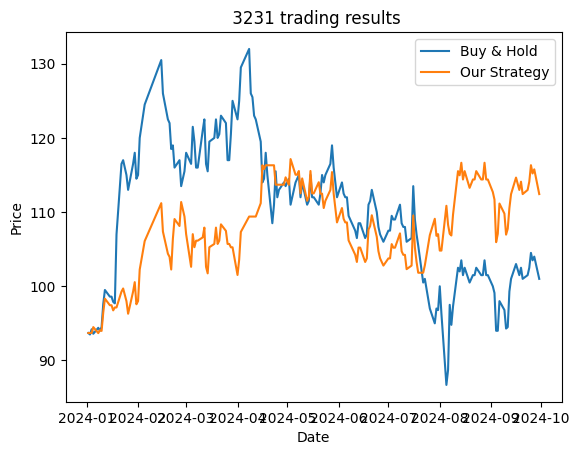

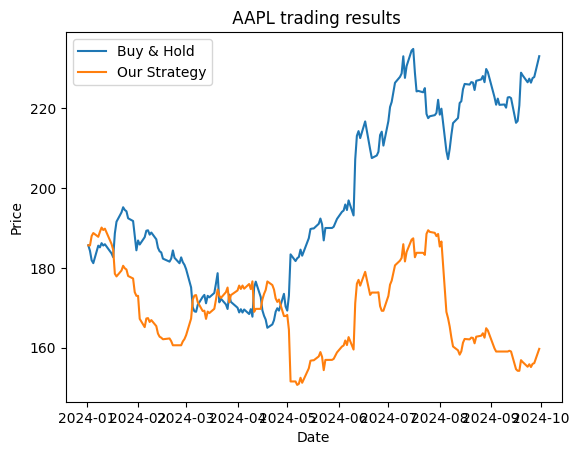

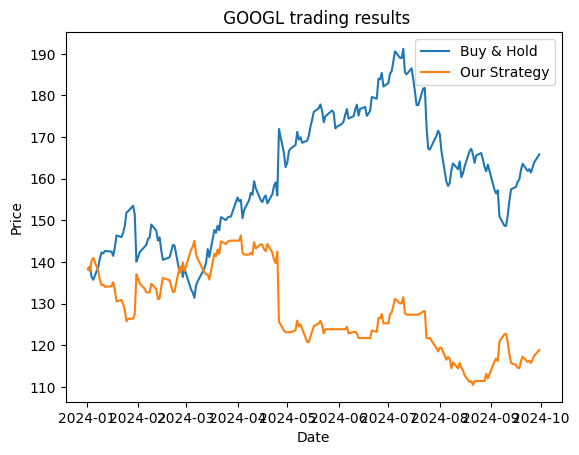

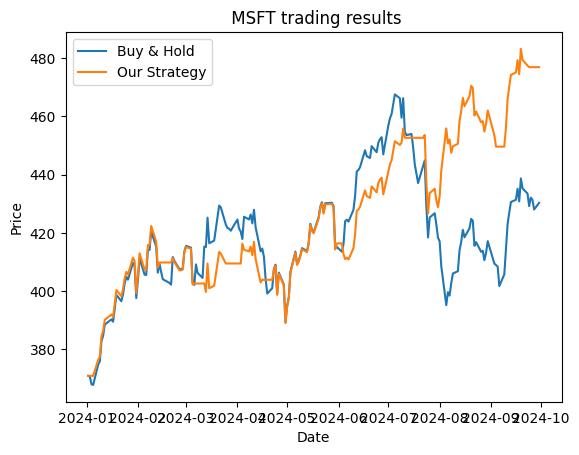

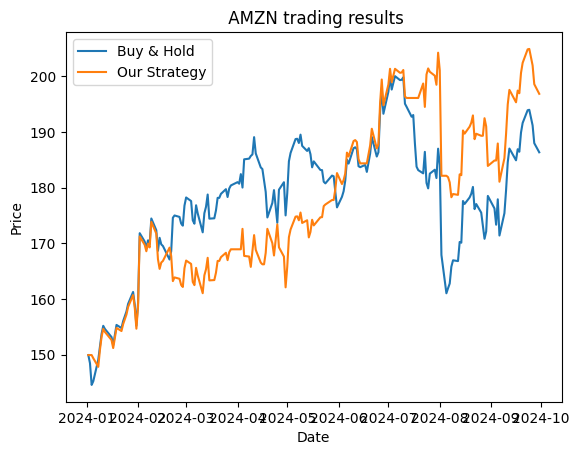

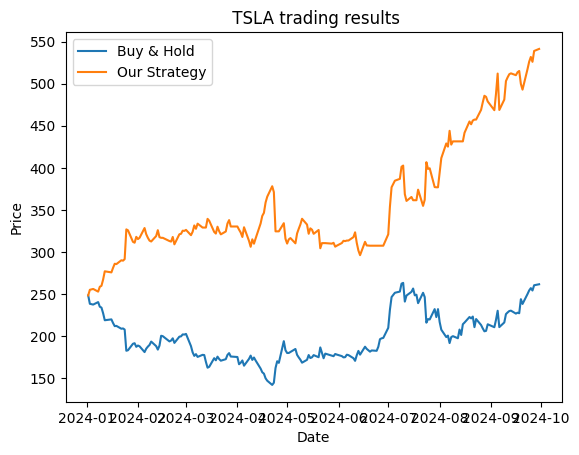

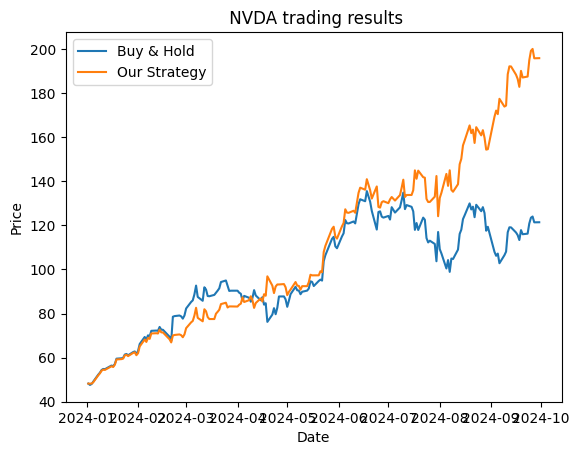

,accuracy,precision,ev,precision_ev
平均值,0.491769,0.490446,0.002947,0.002613
平均值,0.486759,0.479017,0.002985,0.002312
平均值,0.493771,0.496451,0.003017,0.002745
平均值,0.488495,0.493847,0.002752,0.002390
平均值,0.483957,0.493351,0.002778,0.002564
平均值,0.492575,0.493843,0.003320,0.002878
平均值,0.491827,0.491990,0.003045,0.002726
平均值,0.490696,0.490316,0.003232,0.002710
平均值,0.492095,0.487505,0.003085,0.002568
平均值,0.491147,0.488739,0.003088,0.002688


In [4]:
from usable_movement import UsableMovment

avgs = pd.DataFrame()
def runAll(i, avgs):
    stock_results = []
    index = []
    for stock in data:
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
            }
            # print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = UsableMovment(env, i)
            eval_module.generate_factors()
            eval_module.expand_factors(llm_factors=llm)
            train_datarange, test_datarange = eval_module.split_exp()

            df = eval_module.run_taining(1, train_datarange, test_datarange)
            # display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']])

            result = eval_module.get_result(1)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])

        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        plt.title(f" {env['stock_id']} trading results")
        plt.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        plt.plot(dplot, list_stag_balance, label="Our Strategy")  # orange

        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.show()
            
    df_stock_results = pd.DataFrame(stock_results, index=index)
    selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']  # 替換為您需要的欄位名稱
    df_selected = df_stock_results.loc[:, selected_columns]

    columns_to_average = ['accuracy', 'precision', 'ev', 'precision_ev']
    averages = df_selected[columns_to_average].replace('%', '', regex=True).astype(float).mean()
    average_row = pd.DataFrame(averages).T
    average_row.index = ['平均值']
    
    avgs = pd.concat([avgs, average_row])

    df_selected_with_avg = pd.concat([df_selected, average_row])
    df_selected_with_avg['accuracy'] = df_selected_with_avg['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
    df_selected_with_avg['precision'] = df_selected_with_avg['precision'].apply(lambda x: f"{x * 100:.2f}%")

    # display(df_selected_with_avg)
    return avgs

for i in range(1, 11):
    print(i)
    avgs = runAll(i, avgs)

# display(avgs)
# 計算最後一列的平均值
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['最終平均值']

# 將最終平均值添加到 avgs
avgs = pd.concat([avgs, final_average_row])

display(avgs)